In [212]:
import re 
import sys
import argparse
import numpy as np
import pandas as pd
from glob import glob 
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.patches as patches

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 40)
pd.options.display.float_format = '{:.2f}'.format

PATIENT = 'PPCG0086'
INDIR_SCNA = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/battenberg_scna/Subclonal_SCNA_with_Avg_CN'
INDIR_TREES = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/conipher_trees'
INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/dpclust_ccf'

### Loading Batterberg SCNA Calls

In [213]:
def load_battenberg(donor: str) -> pd.DataFrame:
    df = None
    filepaths = glob(f"{INDIR_SCNA}/{donor}*.txt")
    for filepath in filepaths: 
        sample = filepath.split('/')[-1].split('_')[0]
        segs = load_segments(filepath)
        segs['sample'] = sample
        if df is None:
            df = segs.copy()
        else:
            df = pd.concat([df, segs], ignore_index=True)

    assert df is not None
    # df = gapfill_segments(df)
    df['ident'] = df.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
    return df.copy()

def load_segments(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep='\t', header=0)
    df = df.rename(columns={'startpos': 'start', 'endpos': 'end'})
    df['chr'] = df['chr'].astype(str)
    df['start'] = df['start'].astype(int)
    df['end'] = df['end'].astype(int)
    df = df.dropna(subset=['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'frac1_A'])

    def _get_maxval(row: pd.Series) -> float:
        if row.isna()['frac2_A']:
            assert row['frac1_A'] == 1
            return 1.0
        return max(row['frac1_A'], row['frac2_A'])

    df['chr'] = df['chr'].astype('str')
    df['start'] = df['start'].astype('int')
    df['end'] = df['end'].astype('int')
    df['span'] = df['end'] - df['start']
    df['span'] = df['span'].astype(int)
    df['maxval'] = df.apply(_get_maxval, axis=1)
    df['ccf1_A'] = df['frac1_A'] / df['maxval']
    mask = df['frac2_A'].notna()
    df.loc[mask, 'ccf2_A'] = df.loc[mask, 'frac2_A'] / df.loc[mask, 'maxval']
    df = df[['chr', 'start', 'end', 'span', 'nMaj1_A', 'nMin1_A', 'frac1_A', 'ccf1_A', 'nMaj2_A', 'nMin2_A', 'frac2_A', 'ccf2_A']]
    return df

def filter_intervals_minspan(table: pd.DataFrame, min_span: int=100) -> pd.DataFrame:
    # must be at least 100bp 
    df = table.copy()
    df = df[df['span']>=min_span].copy()
    df = df.reset_index(drop=True)
    return df
    
def filter_intervals_normal(table: pd.DataFrame) -> pd.DataFrame:
    # ignore normal CN segments 
    df = table.copy()
    mask1 = (df['chr']!='X') & (df['nMaj1_A']==1) & (df['nMin1_A']==1) & (df['frac1_A']==1) & (df['nMaj2_A'].isna())
    mask2 = (df['chr']=='X') & (df['nMaj1_A']==1) & (df['nMin1_A']==0) & (df['frac1_A']==1) & (df['frac2_A']==0)
    df1 = df.loc[~mask1 & ~mask2].copy()
    # df2 = df.loc[mask1 | mask2].copy()
    # df2['pattern'] = df2.apply(lambda x: f"{int(x['nMaj1_A'])}+{int(x['nMin1_A'])}", axis=1)
    # print(df2.groupby('chr')['pattern'].value_counts().unstack().fillna(0).astype(int))
    df1 = df1.reset_index(drop=True)
    return df1

def validate_intervals(df: pd.DataFrame) -> None:
    df['span'] = df['end'] - df['start']
    df = df.sort_values(['sample', 'chr', 'start'])
    df = df.reset_index(drop=True)
    idx_l = []
    for sample in df['sample'].unique():
        for chrom in df['chr'].unique():
            dfslice = df[(df['chr']==chrom) & (df['sample']==sample)]
            if dfslice.shape[0] >= 2:
                for i in range(0, dfslice.shape[0]-1):
                    if dfslice.iloc[i]['span'] <= 1:
                        idx_l.append(dfslice.index.to_list()[i])
                    elif dfslice.iloc[i]['end'] > dfslice.iloc[i+1]['start']:
                        idx_l.append(dfslice.index.to_list()[i])
    if len(idx_l) > 0:
        for idx in idx_l:
            print()
            print(df.loc[[idx, idx+1]])
        raise NotImplementedError()
    
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df, min_span=100)
df = filter_intervals_normal(df)
validate_intervals(df)
df.head(10)
    

,chr,start,end,span,nMaj1_A,nMin1_A,frac1_A,ccf1_A,nMaj2_A,nMin2_A,frac2_A,ccf2_A,sample,ident
0,1,762601,3081188,2318587,1.00,1.00,0.96,1.00,2.00,1.00,0.04,0.05,PPCG0086d,PPCG0086d|chr1:762601-3081188
1,1,3083861,3657783,573922,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:3083861-3657783
2,1,6745139,7558789,813650,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:6745139-7558789
3,1,16542876,16848997,306121,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:16542876-16848997
4,1,18135081,18135329,248,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:18135081-18135329
5,1,18297407,22726948,4429541,3.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:18297407-22726948
6,1,22735341,23791737,1056396,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:22735341-23791737
7,1,26646574,27303034,656460,1.00,1.00,0.24,0.31,2.00,1.00,0.76,1.00,PPCG0086d,PPCG0086d|chr1:26646574-27303034
8,1,27305098,27428321,123223,3.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:27305098-27428321
9,1,27432204,28321969,889765,2.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN,PPCG0086d,PPCG0086d|chr1:27432204-28321969


In [214]:
def plot_segments_subclonal(segs: pd.DataFrame, lb: int, ub: int, segment: tuple|None=None, show_subclone: bool=True) -> None:

    if show_subclone:
        df_clonal = segs.copy()
        df_clonal['sample'] = df_clonal['sample'] + ':clonal'

        mask = segs['nMaj2_A'].notna()
        df_subclonal = segs.loc[mask].copy()
        df_subclonal['sample'] = df_subclonal['sample'] + ':subclonal'
        df_subclonal['nMaj1_A'] = df_subclonal['nMaj2_A']
        df_subclonal['nMin1_A'] = df_subclonal['nMin2_A']
        df_subclonal['ccf1_A'] = df_subclonal['ccf2_A']
        df = pd.concat([df_clonal, df_subclonal], ignore_index=True)
    else:
        df = segs.copy()
        
    samples = sorted(list(df['sample'].unique()))
    fig, ax = plt.subplots(figsize=(14, len(samples)*0.5+1))
    ymap = {sample: len(samples)-i for i, sample in enumerate(samples)}
    x_min = min(df['start'].min(), lb)
    x_max = max(df['end'].max(), ub)
    x_range = x_max - x_min
    for _, srec in df.iterrows():
        y = ymap[srec['sample']]
        x0 = (int(srec['start']) - x_min) / x_range
        x1 = (int(srec['end']) - x_min) / x_range

        if srec['sample'].endswith('subclonal'):
            color = 'salmon'
        else:
            color = 'skyblue'
        rect1 = patches.Rectangle(xy=(x0+0.002, y-0.4), width=x1-x0-0.004, height=0.8, linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect1)
        label = f"{int(srec.nMaj1_A)}\n{int(srec.nMin1_A)}"
        ax.annotate(label,
            xy=(0.5, 0.5),          # Center coordinates relative to the rectangle
            xycoords=rect1,         # Use the rectangle's coordinate system
            ha='center',            # Center the text horizontally
            va='center',            # Center the text vertically
            fontsize=10,
            color='black')
        
    ax.set_yticks(list(ymap.values()), list(ymap.keys()))
    poslabels = [f"{int(x//1000)}k" for x in np.linspace(x_min, x_max, num=5)]
    ax.set_xticks(np.linspace(0, 1, num=5), poslabels)
    if segment:
        x0 = (int(segment[0]) - x_min) / x_range
        x1 = (int(segment[1]) - x_min) / x_range
        rect1 = patches.Rectangle(xy=(x0+0.002, 0-0.4), width=x1-x0-0.004, height=0.4, linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect1)
        ax.set_ylim(-1, len(samples)+1)
        ax.axvline(x0, c='black', linestyle='-')
        ax.axvline(x1, c='black', linestyle='-')
    else:
        ax.set_ylim(0, len(samples)+1)

    if lb is not None:
        x = (lb - x_min) / x_range
        ax.axvline(x, c='grey', linestyle='--')
    if ub is not None:
        x = (ub - x_min) / x_range
        ax.axvline(x, c='grey', linestyle='--')
    
    ax.axvline(x, c='grey', linestyle='--')

    ax.set_xlim(-0.05, 1.05)
    plt.show()

def subset_intervals(table: pd.DataFrame, chrom: str, start: int, end: int, tolerance: int=100) -> pd.DataFrame:
    # basic filtering: correct chr & intersecting
    df = table.copy()
    mask1 = df['chr']==chrom
    mask2 = (df['start']<=end+tolerance) & (df['end']>=start-tolerance)
    dfslice = df.loc[mask1&mask2].copy()
    return dfslice

df = load_battenberg(donor='PPCG0086')
tol = 1_000
queries = [
    ('10', 100_000_000, 109_000_000),
    ('1', 20135612, 20454331),
]
for k in queries:
    tol = (k[2]-k[1])//2
    dfslice = subset_intervals(df, chrom=k[0], start=k[1]-tol, end=k[2]+tol, tolerance=0)
    dfslice['start'] = dfslice['start'].clip(lower=k[1]-tol)
    dfslice['end'] = dfslice['end'].clip(upper=k[2]+tol)
    print(dfslice)
    plot_segments_subclonal(dfslice, lb=k[1]-tol, ub=k[2]+tol, segment=(k[1], k[2]), show_subclone=True)

     chr      start        end     span  nMaj1_A  nMin1_A  frac1_A  ccf1_A  nMaj2_A  nMin2_A  frac2_A  ccf2_A     sample                                ident
679   10   95500000   98892231  4124277     1.00     0.00     0.96    1.00     1.00     1.00     0.04    0.04  PPCG0086d    PPCG0086d|chr10:94767954-98892231
680   10   98892871   98899166     6295     1.00     1.00     1.00    1.00      NaN      NaN      NaN     NaN  PPCG0086d    PPCG0086d|chr10:98892871-98899166
681   10   98902297  100583458  1681161     2.00     0.00     1.00    1.00      NaN      NaN      NaN     NaN  PPCG0086d   PPCG0086d|chr10:98902297-100583458
682   10  100634631  101072588   437957     1.00     0.00     1.00    1.00      NaN      NaN      NaN     NaN  PPCG0086d  PPCG0086d|chr10:100634631-101072588
683   10  101118520  105175255  4056735     2.00     0.00     1.00    1.00      NaN      NaN      NaN     NaN  PPCG0086d  PPCG0086d|chr10:101118520-105175255
684   10  105180274  109968084  4787810     1.00    

KeyboardInterrupt: 

### Creating Segments and Clipping Overhangs

In [ ]:
# address error calls eg 3+1/4+1 
# handle overhang segments 

# (overhangs) for each segment: 
# - check 1: the current segment is the start or end of the interval
# - check 2: the number of samples is less than the next/previous segment
# - check 3: the current segment spans a small fraction of the total interval 
# - check 4: the span is large for the next/previous segment
from collections import defaultdict

class SegmentManager:
    
    def __init__(self, df: pd.DataFrame) -> None:
        self.df = df.copy() 
        if 'ident' not in self.df.columns:
            self.df['ident'] = self.df.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
        self.df = self.df.set_index('ident')

        self._segmap = self._init_segments()
        self._neighbors = self._init_neighbors()
        self._clipped_bases = 0
        self.validate_segments()

    @property
    def ordered_segments(self) -> list[tuple]:
        segcoords = list(self._segmap.keys())
        segcoords.sort(key=lambda x: (x[0], x[1]))
        return segcoords

    def load_segment(self, coords: tuple) -> pd.DataFrame:
        ids = self._segmap[coords]
        seg = self.df.loc[ids]
        assert seg.empty or seg['sample'].value_counts().max() == 1
        return seg
    
    def previous_segment(self, coords: tuple) -> tuple|None:
        return self._neighbors['prev'].get(coords, None)
    
    def next_segment(self, coords: tuple) -> tuple|None:
        return self._neighbors['next'].get(coords, None)
    
    def perform_overhang_clip(self, coords: tuple, side: str) -> None:
        # get all battenberg intervals in overhang segment and next segment
        if side not in ['LHS', 'RHS']:
            raise ValueError
        
        if side == 'LHS':
            adj_coords = self._neighbors['next'][coords]
        else:
            adj_coords = self._neighbors['prev'][coords]
        clip_ids = self._segmap[coords]
        other_ids = self._segmap[adj_coords]

        # print('\n--- BEFORE CLIP ---')
        # print('overhanging segment')
        # print(self.load_segment(coords))
        # print('adjacent segment')
        # print(self.load_segment(adj_coords))

        # check that the current segment and the next segment share a boundary
        if side == 'LHS':
            assert coords[2] == adj_coords[1]
        else:
            assert coords[1] == adj_coords[2]

        # check that all batternberg intervals in the current segment are in the next segment
        try: 
            assert len(clip_ids) >= 1
            assert len(other_ids) >= 1
            assert len(set(clip_ids)-set(other_ids)) == 0
        except AssertionError: 
            print()
            print(coords)
            print(adj_coords)
            print(side)
            print()
            print('overhang')
            print(self.load_segment(coords))
            print('other segment')
            print(self.load_segment(adj_coords))
            raise RuntimeError

        # clip these intervals in the main dataframe
        if side == 'LHS':
            next_start = adj_coords[1]
            self.df.loc[clip_ids, 'start'] = next_start
        else:
            prev_end = adj_coords[2]
            self.df.loc[clip_ids, 'end'] = prev_end
        
        # dereference all battenberg intervals in overhang segment (makes it empty)
        self._segmap[coords] = []

        # update clip counter
        self._clipped_bases += coords[2] - coords[1]
        
        # print('\n--- AFTER CLIP ---')
        # print('overhanging segment')
        # print(self.load_segment(coords))
        # print('adjacent segment')
        # print(self.load_segment(adj_coords))
        
    def _init_neighbors(self) -> dict:
        allsegs = self.ordered_segments
        out = {'prev': {}, 'next': {}}
        for i, coords in enumerate(allsegs):
            # previous segment: not the first segment, and chrom must match
            if i != 0 and allsegs[i-1][0] == coords[0]:
                out['prev'][coords] = allsegs[i-1]
            # next segment: not the last segment, and chrom must match
            if i != len(allsegs)-1 and allsegs[i+1][0] == coords[0]:
                out['next'][coords] = allsegs[i+1]
        return out                
        
    def _init_segments(self, chrom_col='chr', start_col='start', end_col='end'):
        """
        Decompose all intervals in df into atomic segments defined by the
        union of all breakpoints, then map each segment to the rows that
        intersect it.

        Returns a dict: (chrom, start, end) -> clipped DataFrame slice
        """
        df = self.df
        out = {}

        for chrom, chrom_df in df.groupby(chrom_col):

            # 1. Gather all breakpoints
            breakpoints = sorted(set(
                chrom_df[start_col].tolist() + chrom_df[end_col].tolist()
            ))

            if len(breakpoints) < 2:
                continue

            # 2. Transform into segments: (current, next-1)
            segments = [(breakpoints[i], breakpoints[i+1])
                        for i in range(len(breakpoints) - 1)]

            # 3. Map each segment to intersecting rows, clipped to segment bounds
            for seg in segments:
                seg_start, seg_end = seg
                if seg_end - seg_start <= 1:
                    print(f"[WARNING]: chr{chrom}: {seg_start}-{seg_end} ({seg_end - seg_start}bp)")
                    continue

                # Rows that intersect this segment
                mask1 = (chrom_df[start_col] <= seg_end) & (chrom_df[end_col] >= seg_start)
                mask2 = (chrom_df[end_col] != seg_start) & (chrom_df[start_col] != seg_end)
                ids = chrom_df[mask1 & mask2].index.to_list()
                out[(chrom, seg_start, seg_end)] = ids

        return out
    
    def validate_segments(self) -> None:
        # every battenberg interval is in at least 1 segment
        df = self.df.copy()
        ids_raw = set(df.index.to_list())
        ids_seg = set()
        for _, ids in self._segmap.items():
            ids_seg.update(ids)
        assert len(ids_raw) == len(ids_seg)
        assert len(ids_raw-ids_seg) == 0
        assert len(ids_seg-ids_raw) == 0

        mask1 = df['span'] != df['end'] - df['start']
        print()
        print(f"total samples: {df['sample'].nunique()}")
        print(f"total segments: {len(self._segmap)}")
        print(f"altered segments: {mask1.sum()}")
        # counts = defaultdict(int)
        # spans = defaultdict(int)
        # total_alt = 0
        for coords, ids in self._segmap.items():
            seg = self.load_segment(coords)
            assert seg.empty or seg['sample'].value_counts().max() == 1
        #     nsamples = seg['sample'].nunique()
        #     counts[nsamples] += 1
        #     spans[nsamples] += coords[2] - coords[1]
        # print()
        # print('Samples per segment (#segs):')
        # for k, v in counts.items():
        #     print(k, v)
        # print()
        # print('Samples per segment (span):')
        # for k, v in spans.items():
        #     print(k, v)

        sample_total_bases = defaultdict(int)
        sample_clipped_bases = defaultdict(int)
        for idx, row in df.iterrows():
            raw_start = int(idx.split(':')[-1].split('-')[0])
            raw_end = int(idx.split(':')[-1].split('-')[-1])
            sample = row['sample']
            raw_span = raw_end - raw_start
            adj_span = row['end'] - row['start']
            sample_total_bases[sample] += adj_span
            sample_clipped_bases[sample] += raw_span - adj_span
        
        print()
        print(f"Span clipped bases: {self._clipped_bases}")
        print(f"Sample clipped bases:")
        temp = pd.DataFrame(index=sorted(df['sample'].unique()))
        temp['total'] = sample_total_bases
        temp['clipped'] = sample_clipped_bases
        temp['clipped (%)'] = temp['clipped'] / temp['total'] * 100
        print(temp)

df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
segman = SegmentManager(df)
segman.validate_segments()

In [ ]:
def is_lhs_overhang(segman: SegmentManager, coords: tuple) -> bool:
    next_coords = segman.next_segment(coords)
    if next_coords is not None:
        curr_seg = segman.load_segment(coords)
        next_seg = segman.load_segment(next_coords)
        if not curr_seg.empty and not next_seg.empty:
            return _is_overhang(coords, curr_seg, next_seg, side='LHS')
    return False

def is_rhs_overhang(segman: SegmentManager, coords: tuple) -> bool:
    prev_coords = segman.previous_segment(coords)
    if prev_coords is not None:
        curr_seg = segman.load_segment(coords)
        prev_seg = segman.load_segment(prev_coords)
        if not curr_seg.empty and not prev_seg.empty:
            return _is_overhang(coords, curr_seg, prev_seg, side='RHS')
    return False

def _is_overhang(coords: tuple, this: pd.DataFrame, other: pd.DataFrame, side: str) -> bool:
    # check 1: (LHS overhang) all intervals in current segment start at the segment start 
    if side=='LHS' and not (this['start']==coords[1]).all():
        return False
    # check 1: (RHS overhang) all intervals in current segment end at the segment end 
    if side=='RHS' and not (this['end']==coords[2]).all():
        return False
    # check 2: the number of samples is less than the other segment
    if this['sample'].nunique() >= other['sample'].nunique():
        return False 
    # check 3: the current segment spans a small fraction of the total interval 
    seg_span = coords[2] - coords[1]
    max_span = this['span'].max()
    if seg_span > 0.1 * max_span:
        return False 
    return True

def clip_overhangs(segman: SegmentManager) -> SegmentManager:
    for coords in segman.ordered_segments:
        if is_lhs_overhang(segman, coords):
            segman.perform_overhang_clip(coords, side='LHS')
        elif is_rhs_overhang(segman, coords):
            segman.perform_overhang_clip(coords, side='RHS')
    return segman

df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
segman = SegmentManager(df)
segman = clip_overhangs(segman)
segman.validate_segments()

# tol = 1000
# i = 0 
# for coords in segman.ordered_segments:
#     chrom, start, end = coords
#     lb = start - (end-start)//4
#     ub = end + (end-start)//4
    
#     clipped = False
#     if is_lhs_overhang(segman, coords):
#         # print(f'\n\nLHS overhang: chr{chrom}, {start}-{end}')
#         segman.perform_overhang_clip(coords, side='LHS')
#         clipped = True 
#     elif is_rhs_overhang(segman, coords):
#         # print(f'\n\nRHS overhang: chr{chrom}, {start}-{end}')
#         segman.perform_overhang_clip(coords, side='RHS')
#         clipped = True 
        
#     # if clipped:
#     #     print('RAW')
#     #     dfslice = subset_intervals(df, chrom=chrom, start=start, end=end, tolerance=tol)
#     #     dfslice['start'] = dfslice['start'].clip(lower=lb)
#     #     dfslice['end'] = dfslice['end'].clip(upper=ub)
#     #     plot_segments_subclonal(dfslice, lb=lb, ub=ub, segment=(start, end), show_subclone=True)
#     #     print('CLIPPED')
#     #     dfslice = subset_intervals(segman.df, chrom=chrom, start=start, end=end, tolerance=tol)
#     #     dfslice['start'] = dfslice['start'].clip(lower=lb)
#     #     dfslice['end'] = dfslice['end'].clip(upper=ub)
#     #     plot_segments_subclonal(dfslice, lb=lb, ub=ub, segment=(start, end), show_subclone=True)
#     #     print(dfslice.sort_values(['start', 'sample']))
    
#     i += 1
#     # if i == 10:
#     #     break 

# segman.validate_segments()

### Converting Segments to Events

In [ ]:
LOW_CCF_THRESH = 0.25 

def explode_parts(seg: pd.DataFrame) -> pd.DataFrame:
    lhs = seg.copy()
    rhs = seg[(seg['frac2_A'].notna()) & (seg['frac2_A']!=0)].copy()
    lhs = lhs.rename(columns={'nMaj1_A': 'nMaj', 'nMin1_A': 'nMin', 'frac1_A': 'frac', 'ccf1_A': 'ccf'})
    rhs = rhs.rename(columns={'nMaj2_A': 'nMaj', 'nMin2_A': 'nMin', 'frac2_A': 'frac', 'ccf2_A': 'ccf'})
    df = pd.concat([rhs, lhs], ignore_index=True)
    df['ident'] = df.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1) 
    df['pattern'] = df.apply(lambda x: f"{int(x['nMaj'])}+{int(x['nMin'])}", axis=1)
    df['tcn'] = df['nMaj'] + df['nMin']
    df = df[['ident', 'sample',  'pattern', 'tcn', 'nMaj', 'nMin', 'frac', 'ccf']].copy()
    df = df.sort_values(by=['sample', 'tcn'], ascending=[True, False])
    return df 


class EventGenerator:
    def __init__(self) -> None:
        self.declared_normal = 0 
        self.method_counts = defaultdict(int)
    
    def generate_event(self, coords: tuple, table: pd.DataFrame) -> pd.DataFrame|None:
        df = table.copy()

        if multi_sample_normal(coords, df):
            self.declared_normal += 1
            return None
        if single_pattern(df):
            self.method_counts['single CN state'] += 1
            return df.copy()
        if single_sample(df):
            self.method_counts['single sample'] += 1
            return genevent_single_sample(coords, df)
        if multi_sample_no_split_solutions(df):
            self.method_counts['multi-sample no-multipart'] += 1
            return df.copy()
        pat = multi_sample_shared_pattern(coords, df)
        if pat is not None:
            self.method_counts['multi-sample shared CN state'] += 1
            return genevent_shared_pattern(df, pat)
        if multi_sample_no_normal(coords, df):
            self.method_counts['multi-sample best CN state parsimony'] += 1
            return genevent_best_pattern_parsimony(df)
        else:
            self.method_counts['multi-sample highest CN state'] += 1
            return genevent_highest_nonnormal_fracs(coords, df)

def multi_sample_normal(coords: tuple, df: pd.DataFrame) -> bool:
    NPAT = '1+1' if coords[0] != 'X' else '1+0'
    if df['sample'].nunique() <= 1:
        return False
    all_samples = set(df['sample'].unique())
    has_normal = set(df[(df['pattern']==NPAT) & (df['frac']>=0.5)]['sample'].unique())
    return all_samples == has_normal

def multi_sample_no_normal(coords: tuple, df: pd.DataFrame) -> bool:
    NPAT = '1+1' if coords[0] != 'X' else '1+0'
    if df['sample'].nunique() <= 1:
        return False
    return NPAT not in set(df['pattern'].unique())

def multi_sample_no_split_solutions(df: pd.DataFrame) -> bool:
    if df['sample'].nunique() <= 1:
        return False
    return df['sample'].nunique() == df.shape[0]

def multi_sample_shared_pattern(coords: tuple, df: pd.DataFrame) -> str|None:
    NPAT = '1+1' if coords[0] != 'X' else '1+0'
    if df['sample'].nunique() <= 1:
        return None
    nsamples = df['sample'].nunique()
    patterns = df['pattern'].unique()
    counts = pd.DataFrame(index=patterns)
    counts['n_samples'] = df[df['frac']>=LOW_CCF_THRESH]['pattern'].value_counts()
    counts['avg_frac'] = df[df['frac']>=LOW_CCF_THRESH].groupby('pattern')['frac'].mean()
    counts = counts.sort_values(['n_samples', 'avg_frac'], ascending=False)
    best = counts[counts['n_samples']==nsamples].index.to_list()
    if len(best) == 0:
        return None
    elif len(best) == 1:
        return best[0]
    elif best[0] != NPAT:
        return best[0]
    else:
        return None 

def single_sample(df: pd.DataFrame) -> bool:
    return df['sample'].nunique() == 1

def single_pattern(df: pd.DataFrame) -> bool:
    return df['pattern'].nunique() == 1

def genevent_shared_pattern(df: pd.DataFrame, pattern: str) -> pd.DataFrame:
    return df[df['pattern']==pattern].copy()

def genevent_best_pattern_parsimony(df: pd.DataFrame) -> pd.DataFrame:
    cmap = df[df['frac']>=LOW_CCF_THRESH]['pattern'].value_counts().to_dict()
    df['obs'] = df['pattern'].map(cmap)
    df['obs'] = df['obs'].fillna(0).astype(int)
    dfslice = df.sort_values('obs', ascending=False).drop_duplicates('sample').copy()
    return dfslice

def genevent_single_sample(coords: tuple, df: pd.DataFrame) -> pd.DataFrame:
    NPAT = '1+1' if coords[0] != 'X' else '1+0'
    # single part
    if df.shape[0] == 1:
        return df.copy()

    # multiple parts, one is normal
    dfslice = df[df['pattern']!=NPAT]
    if dfslice.shape[0] == 1:
        return dfslice.copy()
    
    # multiple parts, both not normal
    df = df.sort_values('frac', ascending=False)
    return df.iloc[:1, :].copy()
    
def genevent_highest_nonnormal_fracs(coords: tuple, df: pd.DataFrame) -> pd.DataFrame:
    # samples = set(df['sample'].unique())
    NPAT = '1+1' if coords[0] != 'X' else '1+0'
    dfslice = df[df['pattern']!=NPAT].copy()
    dfslice = dfslice.sort_values('frac', ascending=False).drop_duplicates('sample').copy()
    return dfslice[dfslice['frac']>=LOW_CCF_THRESH].copy()


def generate_all_events(segman: SegmentManager) -> list:
    all_events = []
    n_dropped_samples = 0
    eventgen = EventGenerator()
    for coords in segman.ordered_segments:
        seg = segman.load_segment(coords)
        if seg.empty:
            continue 

        stack = explode_parts(seg)
        event = eventgen.generate_event(coords, stack)
        if event is None:
            continue 
        
        all_events.append((coords, event))
        samples_seg = set(seg['sample'].unique())
        samples_event = set(event['sample'].unique())
        if len(samples_event) < len(samples_seg):
            n_dropped_samples += 1

        if (event['frac']<LOW_CCF_THRESH).sum() > 1:
            print('[WARNING] low fracs')
            print(stack)
            print()
            print(event)

        # chrom, start, end = coords
        # lb = start - (end-start)//4
        # ub = end + (end-start)//4
        # print(f"SEGMENT: span={round(coords[2]-coords[1], -3)//1000}k  {coords}")
        # print('\nNEW CONDITION')
        # print('\nSegment:')
        # print(seg)
        # print('\nExploded:')
        # print(df)
        # plot_segments_subclonal(seg, lb=lb, ub=ub, segment=(start, end), show_subclone=True)
        # break

    print()
    print(f"Total events: {len(all_events)}")
    print(f"Declared normal: {eventgen.declared_normal}")
    print(f"Dropped samples: {n_dropped_samples}")
    print()
    for k, v in eventgen.method_counts.items():
        print(k, v)
    return all_events


df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
segman = SegmentManager(df)
segman = clip_overhangs(segman)
segman.validate_segments()
events = generate_all_events(segman)


[WARNING]: chr8: 30921752-30921753 (1bp)

total samples: 4
total segments: 3360
altered segments: 0

Span clipped bases: 0
Sample clipped bases:
                total  clipped  clipped (%)
PPCG0086a   727693796        0         0.00
PPCG0086c  1261696842        0         0.00
PPCG0086d  1176119108        0         0.00
PPCG0086e   908377143        0         0.00

total samples: 4
total segments: 3360
altered segments: 88

Span clipped bases: 4870016
Sample clipped bases:
                total  clipped  clipped (%)
PPCG0086a   726537340  1156456         0.16
PPCG0086c  1257728102  3968740         0.32
PPCG0086d  1172303820  3815288         0.33
PPCG0086e   907941721   435422         0.05
Total events: 2593
Declared normal: 33
Dropped samples: 131

single CN state 851
single sample 313
multi-sample shared CN state 796
multi-sample no-multipart 243
multi-sample best CN state parsimony 184
multi-sample highest CN state 206


### Assigning To Tree Clones

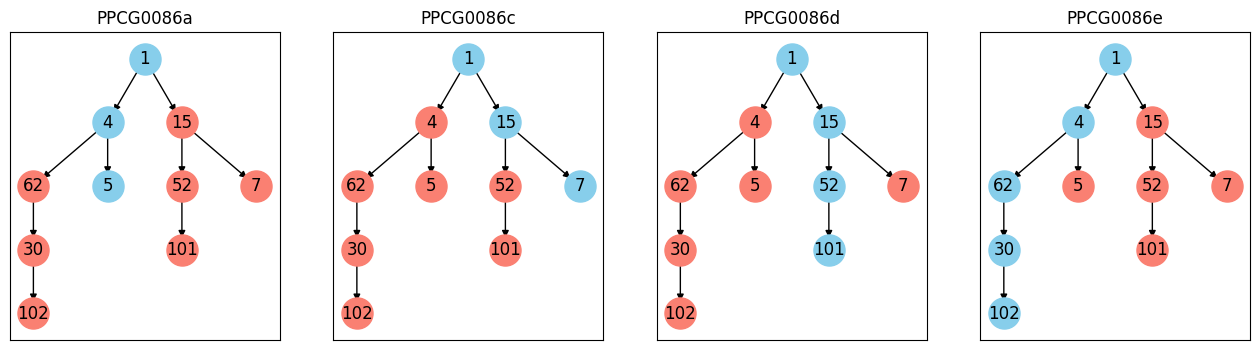

In [ ]:
import networkx as nx 
from networkx.drawing.nx_agraph import graphviz_layout

def load_dpclust(donor: str):
    filepath = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
    df = pd.read_csv(filepath, sep=',', header=0)
    df['Cluster'] = df['Cluster'].apply(lambda x: str(x).replace('_', '').split('.')[0])
    df = df.set_index('Cluster')
    df.columns = [x.replace('_DNA', '') for x in df.columns]
    df = df[[x for x in df.columns if x.startswith('PPCG') or x=='Cluster_Type']].copy()
    return df

def load_conipher(donor: str) -> nx.DiGraph:
    filepath = f"{INDIR_TREES}/{donor}_conipher_tree/allTrees.txt"
    trees = {}
    
    with open(filepath, 'r') as fp:
        line = fp.readline().strip()
        line = fp.readline().strip()
        assert line == '# tree 1'

        name = line.strip('# ')
        T = nx.DiGraph()
        line = fp.readline().strip()
        while line:
            if line.startswith('#'):
                trees[name] = T
                name = line.strip('# ')
                T = nx.DiGraph()
            else:
                parent, child = line.split('\t')
                parent = parent.replace('_', '')
                child = child.replace('_', '')
                T.add_edge(parent, child)
            line = fp.readline().strip()
        trees[name] = T
    
    return trees['tree 1']

def annotate_samples(T: nx.DiGraph, ccfs: pd.DataFrame) -> nx.DiGraph:
    df = ccfs.drop('Cluster_Type', axis=1).T
    for node in T.nodes():
        present = df[df[node]>0].index.to_list()
        T.nodes[node]['samples'] = set(present)
    return T

def draw_tree(T: nx.DiGraph, ccfs: pd.DataFrame) -> None:
    df = ccfs.drop('Cluster_Type', axis=1)
    samples = df.columns.to_list()
    
    i = 0
    ncols = 4 if len(samples) >= 4 else len(samples) % 4
    nrows = len(samples) // 4 
    if len(samples) % 4 != 0:
        nrows += 1
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
    for sample in samples:
        if nrows > 1:
            row = i // 4
            col = i % 4 
            ax = axes[row, col]
        else:
            col = i % 4 
            ax = axes[col]

        pos = graphviz_layout(T, prog='dot')
        present = df[df[sample]>0].index.to_list()
        nl_present = [n for n in T.nodes() if n in present]
        nl_missing = [n for n in T.nodes() if n not in present]
        nx.draw_networkx_nodes(T, pos, nodelist=nl_present, node_color='skyblue', node_size=500, ax=ax)
        nx.draw_networkx_nodes(T, pos, nodelist=nl_missing, node_color='salmon', node_size=500, ax=ax)
        nx.draw_networkx_labels(T, pos, ax=ax)
        nx.draw_networkx_edges(T, pos, ax=ax)
        ax.set_title(sample)
        i += 1
    plt.show()
    plt.close()

ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
draw_tree(T, ccfs)

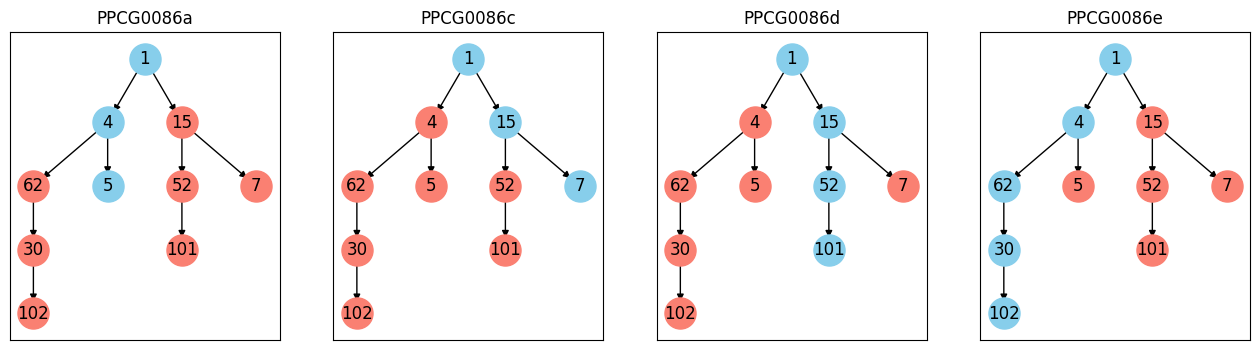

         PPCG0086a  PPCG0086c  PPCG0086d  PPCG0086e Cluster_Type
Cluster                                                         
1             0.99       1.01       1.01       1.00        Trunk
4             0.97       0.00       0.00       1.01         Seed
5             0.96       0.00       0.00       0.00         Leaf
7             0.00       0.33       0.00       0.00         Leaf
101           0.00       0.00       0.28       0.00         Leaf
102           0.00       0.00       0.00       0.11         Leaf
15            0.00       0.97       1.02       0.00       Branch
30            0.00       0.00       0.00       0.35         Leaf
52            0.00       0.00       0.95       0.00         Leaf
62            0.00       0.00       0.00       0.85         Leaf

{'PPCG0086a': 1.0, 'PPCG0086c': 1.0, 'PPCG0086d': 1.0, 'PPCG0086e': 1.0}
winner: 1, score=0.01, exact

{'PPCG0086a': 1.0, 'PPCG0086e': 1.0}
winner: 4, score=0.03, exact

{'PPCG0086c': 1.0, 'PPCG0086d': 1.0}
winner: 15, 

In [ ]:
from collections import defaultdict
from itertools import combinations

class SiteParsimonyAssigner:
    
    def __init__(self, T: nx.DiGraph, ccfs: pd.DataFrame) -> None:
        self._T = T
        self._ccfs = ccfs.drop('Cluster_Type', axis=1).clip(lower=0, upper=1).copy()
        self._sampat2clones_LUT = self._generate_sampat2clones_LUT()
        self._clone2ccfs_LUT = self._generate_clone2ccfs_LUT()
        # print('\n_sampat2clones_LUT')
        # for k, v in self._sampat2clones_LUT.items():
        #     print(k, v)
        # print('\n_clone2ccfs_LUT')
        # for k, v in self._clone2ccfs_LUT.items():
        #     print(k, v)

    def assign(self, obs_samples2ccfs: dict[str, float]) -> tuple[str, float, str]:
        assert len(obs_samples2ccfs) > 0
        obs_sams = sorted(list(obs_samples2ccfs.keys()))
        candidates = self._sampat2clones_LUT[tuple(obs_sams)]

        if len(candidates) == 0:
            raise RuntimeError
        
        # if len(candidates) == 1:
        #     if set(obs_samples2ccfs.keys()) == set(list()[])
        #     return list(candidates)[0], 'exact'
        
        scores = []
        for clone in candidates:
            dpc_samples2ccfs = self._clone2ccfs_LUT[clone]
            assert len(set(obs_samples2ccfs.keys()) - set(dpc_samples2ccfs.keys())) == 0
            score = 0
            statement = 'exact'
            for sample in dpc_samples2ccfs.keys():
                if sample not in obs_samples2ccfs:
                    score += 1 # penalty for variant not being witnessed in a sample it should 
                    statement = 'inexact'
                    continue
                score += abs(dpc_samples2ccfs[sample] - obs_samples2ccfs[sample])
            scores.append((clone, score, statement))
        
        scores = sorted(scores, key=lambda x: x[1])
        return scores[0]

    def _generate_clone2ccfs_LUT(self) -> dict:
        out = dict()
        for clone, row in self._ccfs.iterrows():
            out[clone] = row[row>0].to_dict()
        return out

    def _generate_sampat2clones_LUT(self) -> dict:
        out = dict()
        
        samples = sorted(self._ccfs.columns.to_list())
        itemsets = []
        for m in range(1, len(samples) + 1):
            itemsets.extend(combinations(samples, m))

        for comb in itemsets:
            out[comb] = self._get_clones(comb)
        return out

    def _get_clones(self, samples) -> set[str]:
        out = set()
        for node in nx.topological_sort(self._T):
            descendants = {node} | nx.descendants(self._T, node)
            reachable = set()
            for desc in descendants:
                reachable.update(self._T.nodes[desc]['samples'])
            if len(set(samples) - reachable) == 0:
                out.add(node)
        return out

def all_combinations(items):
    """
    Returns all unique combinations of items, for every possible size
    from 1 to len(items).
    """
    result = []
    for m in range(1, len(items) + 1):
        result.extend(combinations(items, m))
    # return [sorted(x) for x in result]
    return result


ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
samples = ccfs.drop('Cluster_Type', axis=1).columns.to_list()
draw_tree(T, ccfs)
print(ccfs)

assigner = SiteParsimonyAssigner(T, ccfs) 
tests = [
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086a': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
    {'PPCG0086d': 0.28},
    {'PPCG0086d': 0.95},
    {'PPCG0086e': 0.85},
    {'PPCG0086e': 0.11},
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
]
for test in tests:
    print()
    print(test)
    clone, score, is_exact = assigner.assign(obs_samples2ccfs=test)
    print(f"winner: {clone}, score={round(score, 2)}, {is_exact}")


In [215]:
print('loading battenberg calls')
df = load_battenberg(donor='PPCG0086')
print('filtering battenberg calls')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
print('converting to segments')
segman = SegmentManager(df)
print('clipping overhanging intervals')
segman = clip_overhangs(segman)
segman.validate_segments()
print('generating events')
events = generate_all_events(segman)

colnames = ['sample', 'coords', 'segment', 'cn_state', 'tcn', 'frac', 'clone', 'parsimony']
table = pd.DataFrame(columns=colnames)
for coords, event in events:
    obs = event.copy()
    obs_dict = obs.set_index('sample')['frac'].to_dict()
    clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict)
    obs['coords'] = obs['ident'].apply(lambda x: x.split('|')[1])
    obs['segment'] = f"chr{coords[0]}:{coords[1]}-{coords[2]}"
    obs['clone'] = clone
    obs['parsimony'] = is_exact
    obs['cn_state'] = obs['pattern']
    obs = obs[colnames].copy()
    table = pd.concat([table, obs], ignore_index=True)

table.head()


loading battenberg calls
filtering battenberg calls
converting to segments
[WARNING]: chr8: 30921752-30921753 (1bp)

total samples: 4
total segments: 3360
altered segments: 0

Span clipped bases: 0
Sample clipped bases:
                total  clipped  clipped (%)
PPCG0086a   727693796        0         0.00
PPCG0086c  1261696842        0         0.00
PPCG0086d  1176119108        0         0.00
PPCG0086e   908377143        0         0.00
clipping overhanging intervals

total samples: 4
total segments: 3360
altered segments: 88

Span clipped bases: 4870016
Sample clipped bases:
                total  clipped  clipped (%)
PPCG0086a   726537340  1156456         0.16
PPCG0086c  1257728102  3968740         0.32
PPCG0086d  1172303820  3815288         0.33
PPCG0086e   907941721   435422         0.05
generating events
Total events: 2593
Dropped samples: 131


,sample,coords,segment,cn_state,tcn,frac,clone,parsimony
0,PPCG0086a,chr1:3088742-3644085,chr1:3088742-3644085,2+1,3.00,1.00,1,exact
1,PPCG0086c,chr1:3088742-3644085,chr1:3088742-3644085,2+1,3.00,1.00,1,exact
2,PPCG0086d,chr1:3088742-3644085,chr1:3088742-3644085,2+1,3.00,1.00,1,exact
3,PPCG0086e,chr1:3088742-3644085,chr1:3088742-3644085,2+1,3.00,1.00,1,exact
4,PPCG0086a,chr1:6745139-7558789,chr1:6745139-7558789,2+1,3.00,1.00,1,exact


In [222]:
print(table.shape[0])
print((table['coords']==table['segment']).sum())
print()
print(table.drop_duplicates('segment')['parsimony'].value_counts())
table['span'] = table['segment'].apply(lambda x: int(x.split('-')[-1]) - int(x.split(':')[1].split('-')[0]))
print()
print(table.drop_duplicates('segment').groupby('parsimony')['span'].sum())
print()
counts = table.drop_duplicates('segment').groupby('clone')['span'].sum().to_frame()
counts['span (%)'] = counts['span'] / counts['span'].sum() * 100
print(counts)
table[table['coords']!=table['segment']].head(10)

6893
1997

parsimony
exact      1929
inexact     664
Name: count, dtype: int64

parsimony
exact      1422579091
inexact      78659431
Name: span, dtype: int64

            span  span (%)
clone                     
1      698329820     46.52
101     59265591      3.95
102    101999538      6.79
15     370683114     24.69
30      24841278      1.65
4       19608258      1.31
5       21495165      1.43
52      49941697      3.33
62      16978549      1.13
7      138095512      9.20


,sample,coords,segment,cn_state,tcn,frac,clone,parsimony,span
25,PPCG0086c,chr1:18297407-20105304,chr1:18297407-19194939,3+1,4.00,0.79,1,exact,897532
26,PPCG0086d,chr1:18297407-22726948,chr1:18297407-19194939,3+1,4.00,1.00,1,exact,897532
27,PPCG0086e,chr1:18297407-20803771,chr1:18297407-19194939,2+1,3.00,1.00,1,exact,897532
28,PPCG0086c,chr1:18297407-20105304,chr1:19194939-19197537,3+1,4.00,0.79,1,inexact,2598
29,PPCG0086d,chr1:18297407-22726948,chr1:19194939-19197537,3+1,4.00,1.00,1,inexact,2598
30,PPCG0086e,chr1:18297407-20803771,chr1:19194939-19197537,2+1,3.00,1.00,1,inexact,2598
31,PPCG0086a,chr1:19197537-20803771,chr1:19197537-20105304,2+1,3.00,1.00,1,exact,907767
32,PPCG0086c,chr1:18297407-20105304,chr1:19197537-20105304,3+1,4.00,0.79,1,exact,907767
33,PPCG0086d,chr1:18297407-22726948,chr1:19197537-20105304,3+1,4.00,1.00,1,exact,907767
34,PPCG0086e,chr1:18297407-20803771,chr1:19197537-20105304,2+1,3.00,1.00,1,exact,907767



('1', 3088742, 3644085)
                            ident     sample pattern  tcn  nMaj  nMin  frac  ccf
2  PPCG0086a|chr1:3088742-3644085  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
1  PPCG0086c|chr1:3088742-3644085  PPCG0086c     2+1 3.00  2.00  1.00  1.00 1.00
0  PPCG0086d|chr1:3088742-3644085  PPCG0086d     2+1 3.00  2.00  1.00  1.00 1.00
3  PPCG0086e|chr1:3088742-3644085  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


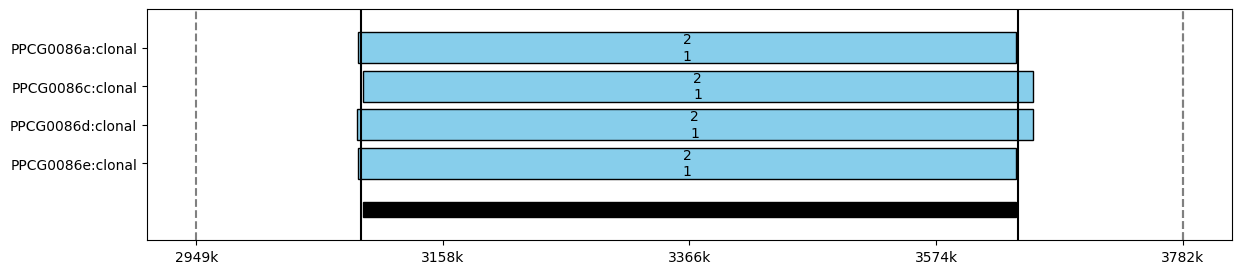


('1', 6745139, 7558789)
                            ident     sample pattern  tcn  nMaj  nMin  frac  ccf
2  PPCG0086a|chr1:6745139-7558789  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
1  PPCG0086c|chr1:6745139-7558789  PPCG0086c     2+1 3.00  2.00  1.00  1.00 1.00
0  PPCG0086d|chr1:6745139-7558789  PPCG0086d     2+1 3.00  2.00  1.00  1.00 1.00
3  PPCG0086e|chr1:6745139-7558789  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


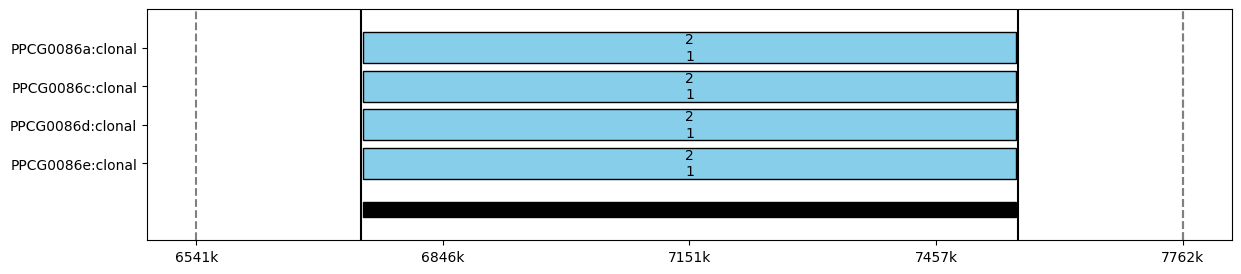


('1', 8909389, 11056694)
                             ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086e|chr1:8909389-11056694  PPCG0086e     1+0 1.00  1.00  0.00  0.89 1.00


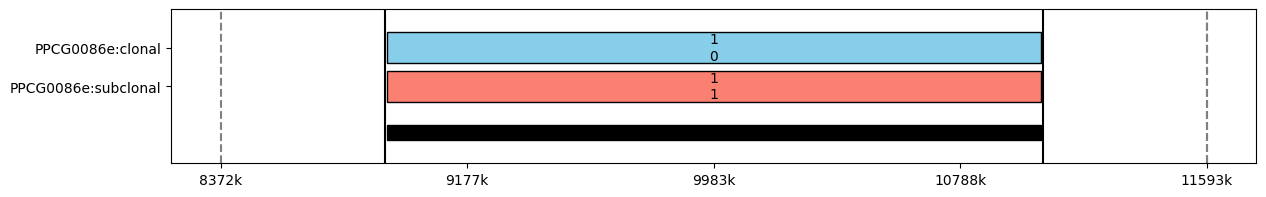


('1', 11058125, 11266044)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086e|chr1:11058125-11266044  PPCG0086e     1+0 1.00  1.00  0.00  0.82 1.00


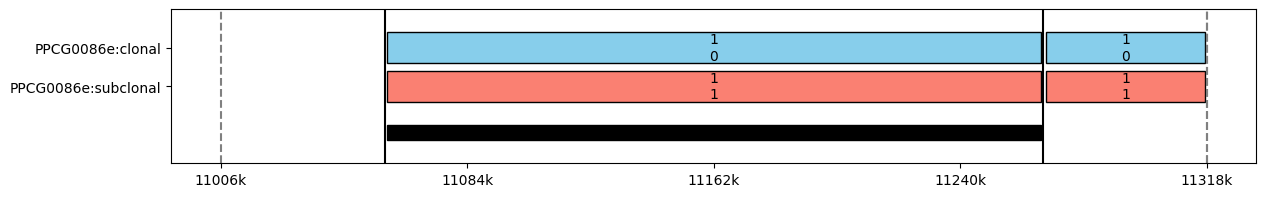


('1', 11266464, 14969869)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086e|chr1:11266464-14969869  PPCG0086e     1+0 1.00  1.00  0.00  0.89 1.00


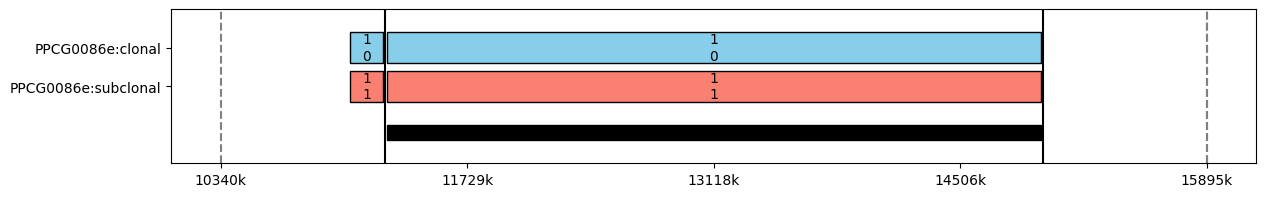


('1', 14972645, 15817319)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086e|chr1:14972645-15817319  PPCG0086e     1+0 1.00  1.00  0.00  0.90 1.00


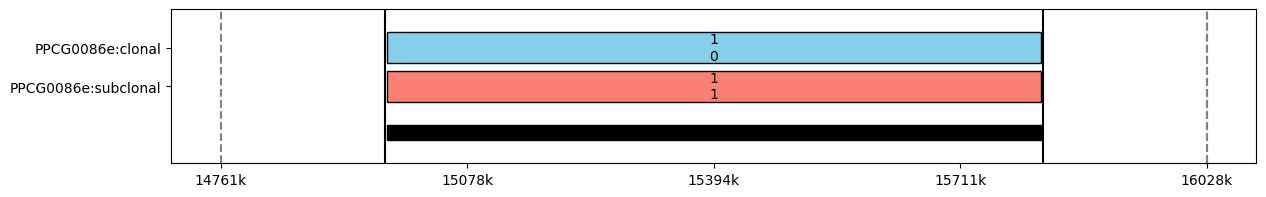


('1', 15820607, 15927803)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086e|chr1:15820607-15927803  PPCG0086e     1+0 1.00  1.00  0.00  0.92 1.00


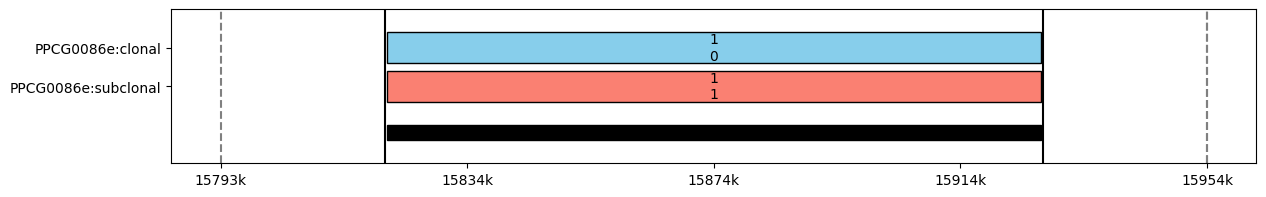


('1', 15941469, 15947102)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
0  PPCG0086e|chr1:15941469-15947102  PPCG0086e     1+0 1.00  1.00  0.00  1.00 1.00


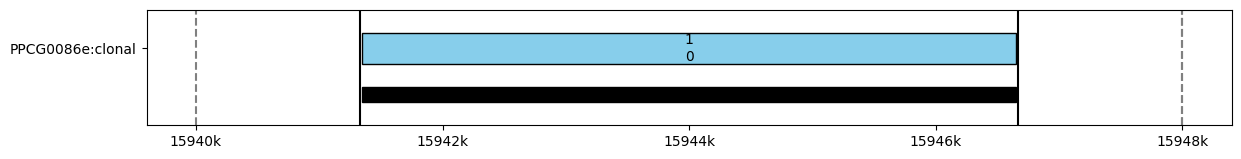


('1', 16543346, 16848997)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
3  PPCG0086a|chr1:16543346-16848997  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
2  PPCG0086c|chr1:16543346-16848997  PPCG0086c     2+1 3.00  2.00  1.00  0.71 1.00
1  PPCG0086d|chr1:16543346-16848997  PPCG0086d     2+1 3.00  2.00  1.00  1.00 1.00
4  PPCG0086e|chr1:16543346-16848997  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


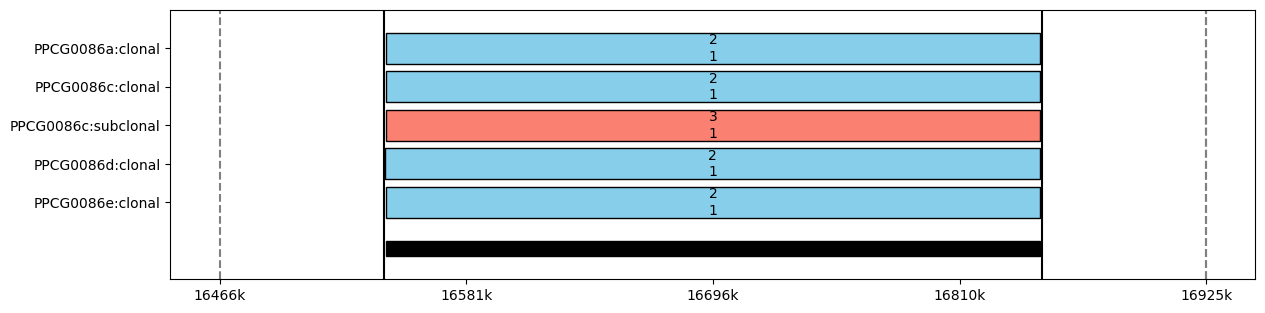


('1', 17276627, 18133242)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
0  PPCG0086e|chr1:17276627-18133242  PPCG0086e     2+1 3.00  2.00  1.00  0.09 0.10


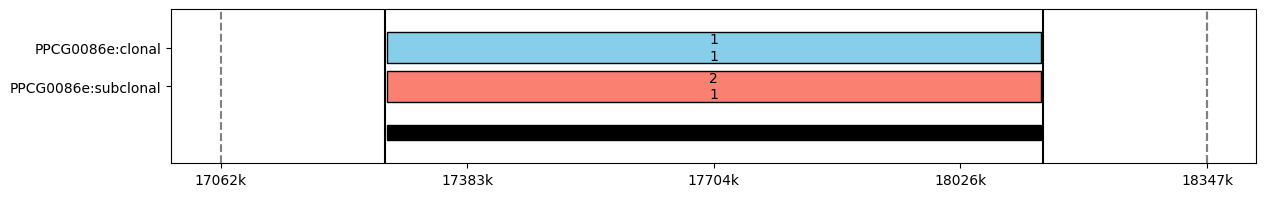


('1', 18135081, 18135329)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
2  PPCG0086a|chr1:18135081-18135329  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
1  PPCG0086c|chr1:18135081-18135329  PPCG0086c     2+2 4.00  2.00  2.00  1.00 1.00
0  PPCG0086d|chr1:18135081-18135329  PPCG0086d     2+1 3.00  2.00  1.00  1.00 1.00
3  PPCG0086e|chr1:18135081-18135329  PPCG0086e     3+2 5.00  3.00  2.00  1.00 1.00


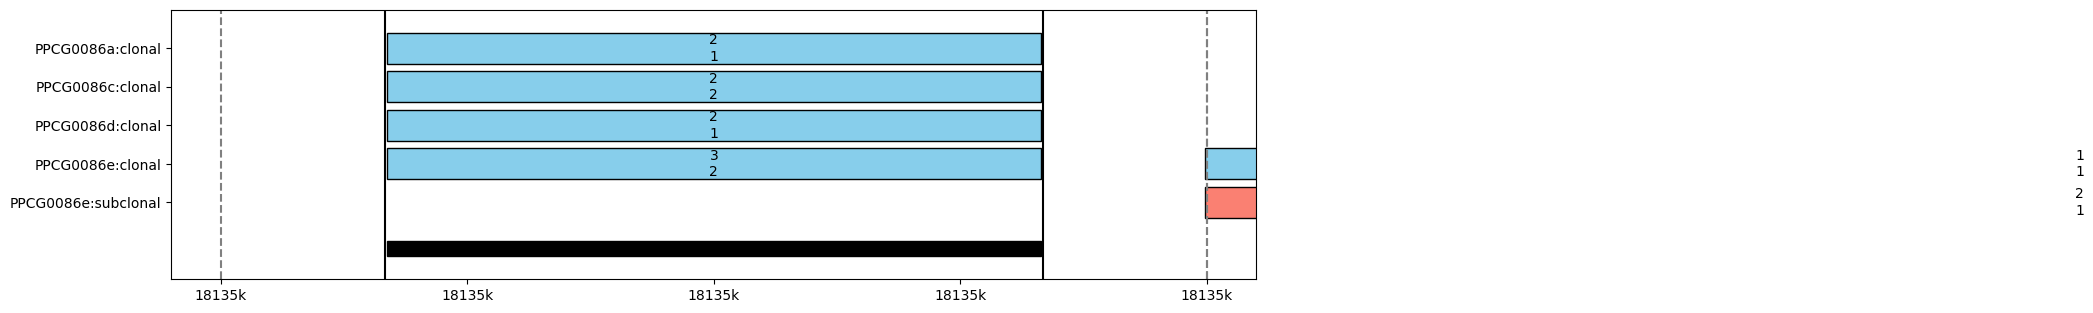


('1', 18136049, 18296015)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
0  PPCG0086e|chr1:18136049-18296015  PPCG0086e     2+1 3.00  2.00  1.00  0.06 0.07


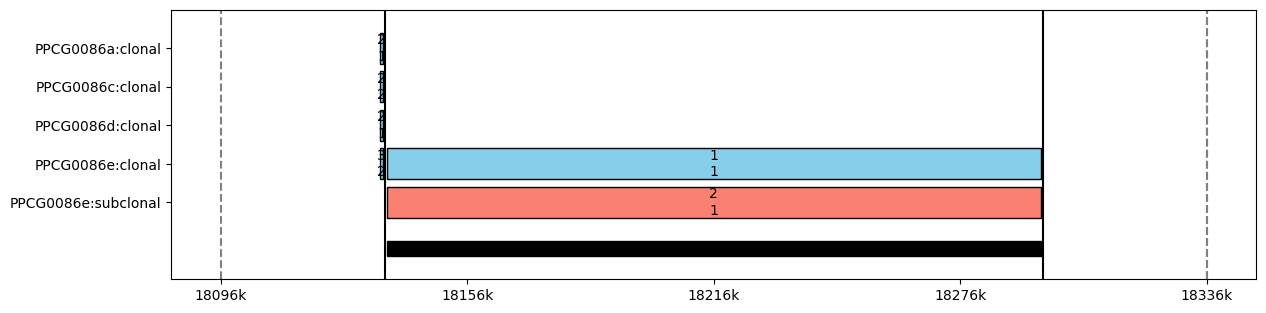


('1', 18297407, 19194939)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf  obs
3  PPCG0086a|chr1:18297407-19194939  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00    2
2  PPCG0086c|chr1:18297407-20105304  PPCG0086c     3+1 4.00  3.00  1.00  0.79 1.00    2
1  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00    2
4  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00    2


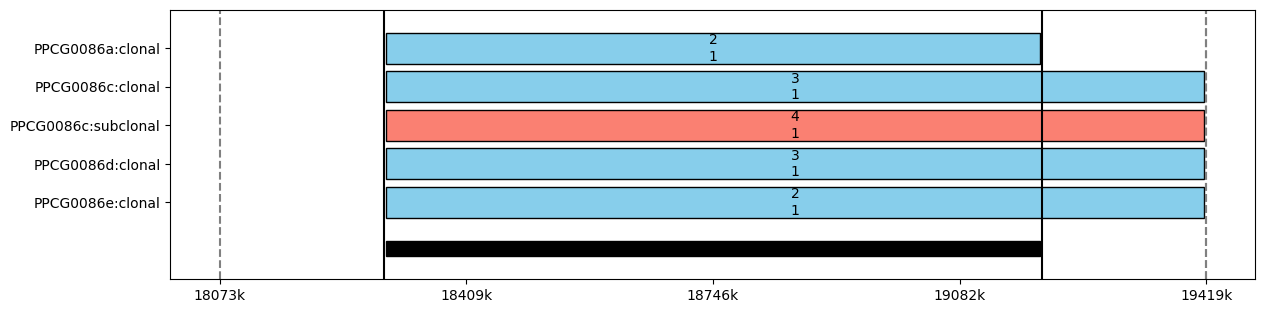


('1', 19194939, 19197537)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf  obs
2  PPCG0086c|chr1:18297407-20105304  PPCG0086c     3+1 4.00  3.00  1.00  0.79 1.00    2
1  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00    2
3  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00    1


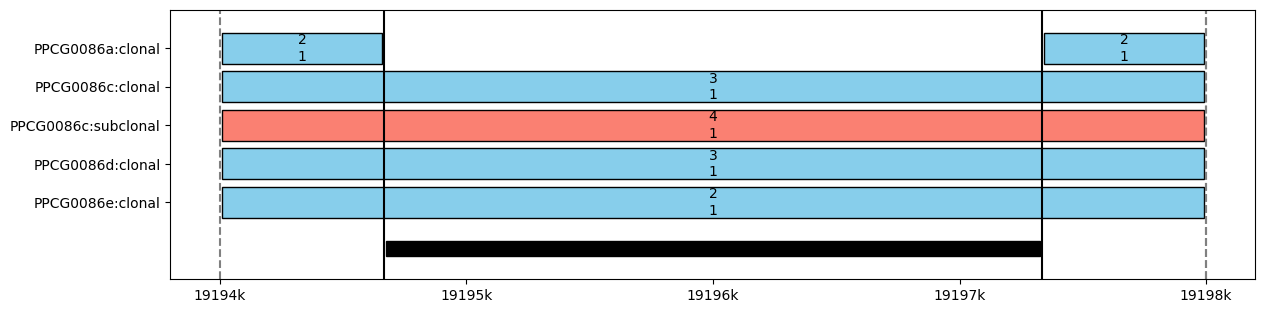


('1', 19197537, 20105304)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf  obs
3  PPCG0086a|chr1:19197537-20803771  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00    2
2  PPCG0086c|chr1:18297407-20105304  PPCG0086c     3+1 4.00  3.00  1.00  0.79 1.00    2
1  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00    2
4  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00    2


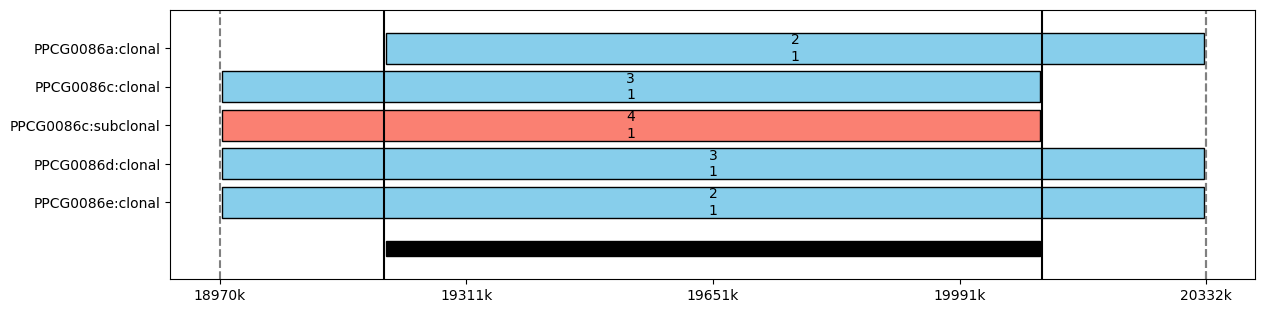


('1', 20105304, 20135612)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086a|chr1:19197537-20803771  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
0  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00
2  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


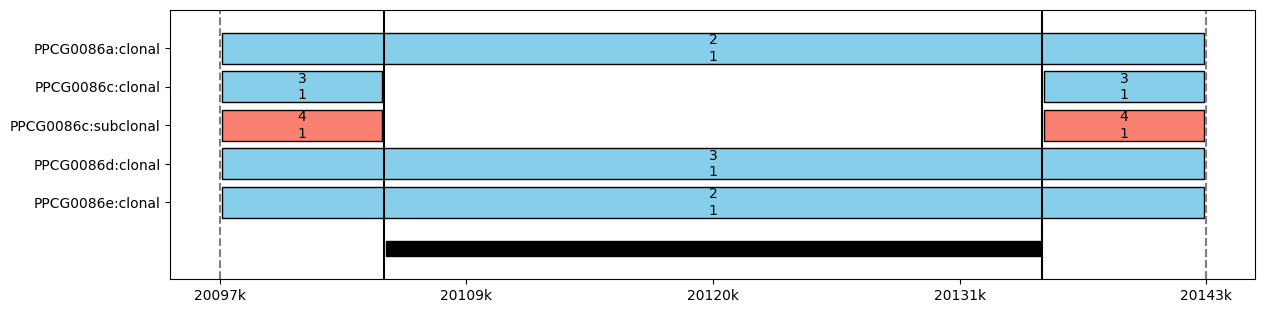


('1', 20135612, 20454331)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf  obs
3  PPCG0086a|chr1:19197537-20803771  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00    2
2  PPCG0086c|chr1:20135612-20454331  PPCG0086c     3+1 4.00  3.00  1.00  0.47 0.88    2
1  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00    2
4  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00    2


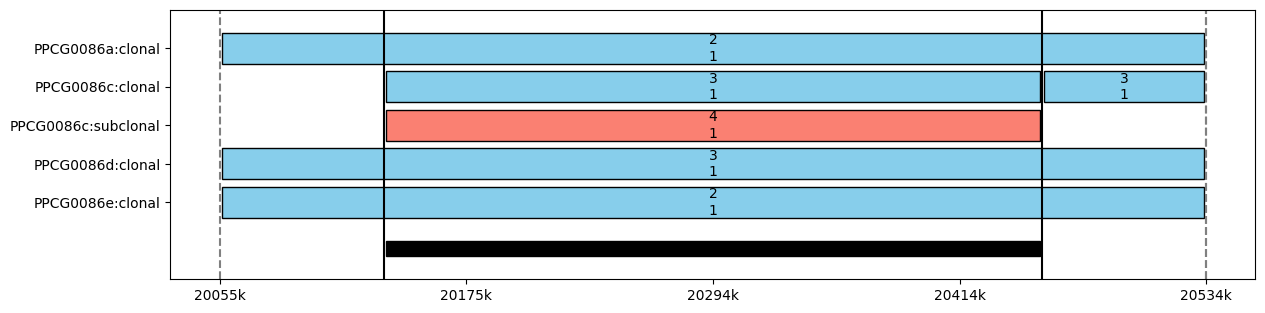


('1', 20454331, 20454609)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086a|chr1:19197537-20803771  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
0  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00
2  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


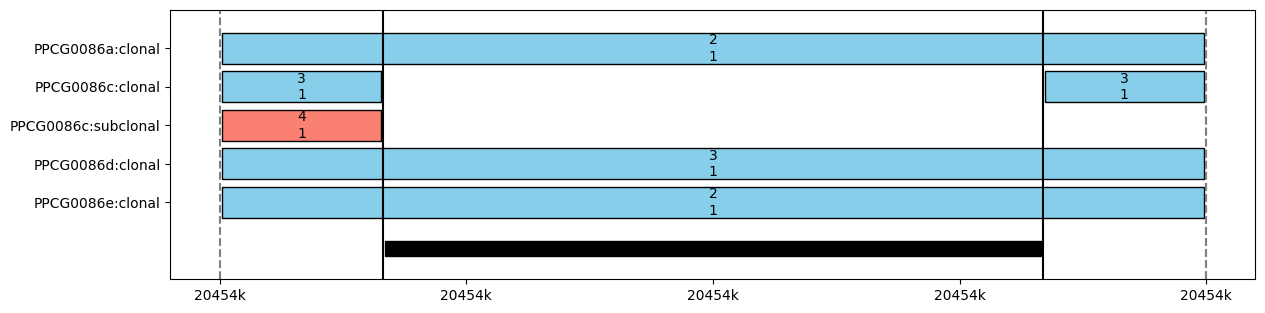


('1', 20454609, 20803771)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
2  PPCG0086a|chr1:19197537-20803771  PPCG0086a     2+1 3.00  2.00  1.00  1.00 1.00
1  PPCG0086c|chr1:20454609-21455236  PPCG0086c     3+1 4.00  3.00  1.00  1.00 1.00
0  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00
3  PPCG0086e|chr1:18297407-20803771  PPCG0086e     2+1 3.00  2.00  1.00  1.00 1.00


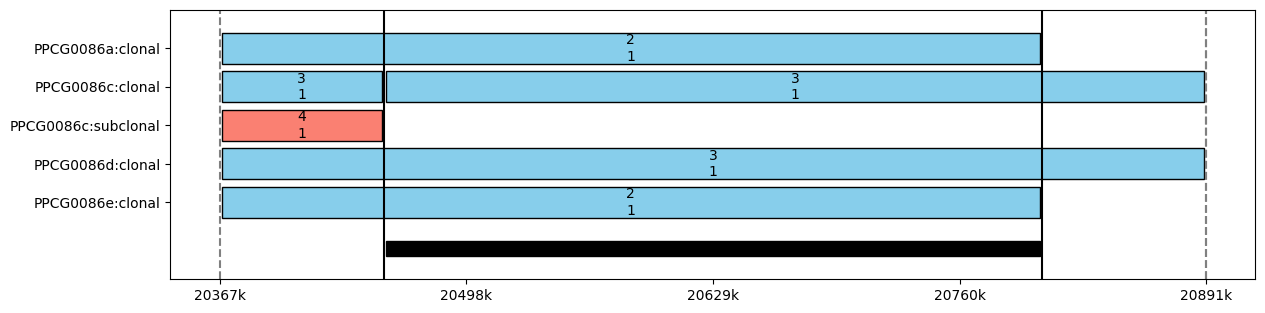


('1', 20803771, 20813488)
                              ident     sample pattern  tcn  nMaj  nMin  frac  ccf
1  PPCG0086c|chr1:20454609-21455236  PPCG0086c     3+1 4.00  3.00  1.00  1.00 1.00
0  PPCG0086d|chr1:18297407-22726948  PPCG0086d     3+1 4.00  3.00  1.00  1.00 1.00


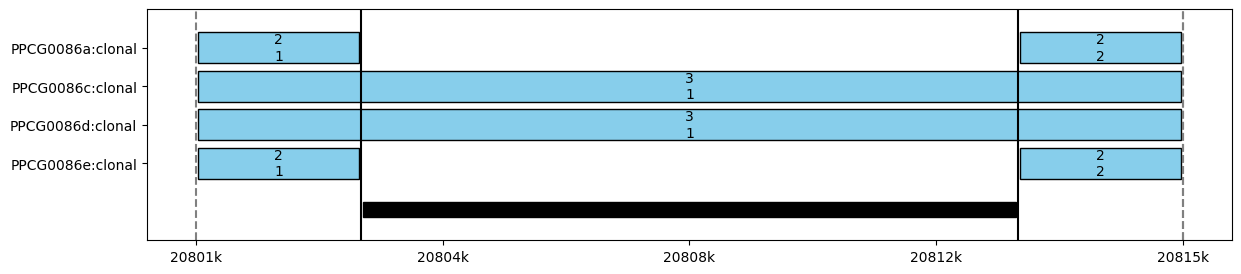

In [ ]:
# for coords, event in events[:20]:
#     obs = event.set_index('sample')['frac'].to_dict()
#     clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs)
#     print()
#     print(coords)
#     print(event)
#     chrom, start, end = coords
#     lb = start - (end-start)//4
#     ub = end + (end-start)//4
#     dfslice = subset_intervals(df, chrom=chrom, start=start, end=end, tolerance=tol)
#     dfslice['start'] = dfslice['start'].clip(lower=lb)
#     dfslice['end'] = dfslice['end'].clip(upper=ub)
#     plot_segments_subclonal(dfslice, lb=lb, ub=ub, segment=(start, end), show_subclone=True)

<br><br><br><br><br><br><br><br><br><br>

In [ ]:
# if one is not normal CN, use dat one. 
def reformat_segments(table: pd.DataFrame) -> pd.DataFrame:
    # if both are not normal, use da most trunkel
    df = table.copy()
    df = annotate_altered_states(df)
    
    df['LHSpattern'] = df.apply(lambda x: f"{int(x['nMaj1_A'])}+{int(x['nMin1_A'])}", axis=1)
    df['LHStot'] = df['nMaj1_A'] + df['nMin1_A']
    df['LHStot'] = df['LHStot'].astype(float)
    df['LHSccf'] = df['ccf1_A']

    mask = df['part2']!='null'
    df.loc[mask, 'RHSpattern'] = df.loc[mask].apply(lambda x: f"{int(x['nMaj2_A'])}+{int(x['nMin2_A'])}", axis=1)
    df.loc[mask, 'RHStot'] = df.loc[mask, 'nMaj2_A'] + df.loc[mask, 'nMin2_A']
    df['RHSccf'] = df['ccf2_A']

    df = df[['sample', 'chr', 'start', 'end', 'LHSpattern', 'LHStot', 'LHSccf', 'RHSpattern', 'RHStot', 'RHSccf']].copy()
    return df

def make_events(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df['swapped'] = False

    data = []

    # malformed input
    if df.shape[0] == 0:
        raise RuntimeError
    
    # single sample
    elif df.shape[0] == 1:
        row = df.iloc[0]
        if row['LHSpattern']!='1+1':
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
        if row.isna()['RHSpattern']==False and row['RHSpattern']!='1+1':
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['RHSpattern'], row['RHSccf'], 'event2'))

    # multiple samples, none have RHS (all clonal)
    elif df['RHSpattern'].isna().all():
        for _, row in df.iterrows():
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
    
    # multiple samples, some have RHS (subclonal)
    elif df['RHSpattern'].notna().any():
        df = handle_swaps(df)
        for _, row in df.iterrows():
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
        for i, pat in enumerate(list(df[df['RHSpattern'].notna()]['RHSpattern'].unique())):
            for _, row in df.iterrows():
                if row['RHSpattern'] == pat:
                    data.append((row['sample'], row['chr'], row['start'], row['end'], row['RHSpattern'], row['RHSccf'], f'event{i+2}'))

    df = pd.DataFrame.from_records(data, columns=['sample', 'chr', 'start', 'end', 'pattern', 'ccf', 'event'])
    df = df[df['pattern']!='1+1'].copy()
    return df

def handle_swaps(df: pd.DataFrame) -> pd.DataFrame:
    # all LHS have same pattern
    if df['LHSpattern'].nunique() == 1:
        return df
    
    all_samples = list(df['sample'].unique())
    all_patterns = list(set(df['LHSpattern'].to_list() + df[df['RHSpattern'].notna()]['RHSpattern'].to_list()))
    vcs = df['LHSpattern'].value_counts()
    most_common_lhs = set(vcs[vcs==vcs.max()].index.to_list())

    counts = pd.DataFrame(data=0, index=all_samples, columns=all_patterns)
    for idx, row in df.iterrows():
        counts.loc[row['sample'], row['LHSpattern']] = 1
        if row.notna()['RHSpattern']:
            counts.loc[row['sample'], row['RHSpattern']] = 1

    # check if all donors have a particular pattern.
    pattern, side = None, None
    for col in counts.columns:
        if counts[col].sum() == len(all_samples):
            if col in most_common_lhs:
                pattern, side = col, 'LHS'
            else:
                pattern, side = col, 'RHS'

    # if not, if there is a most common LHS pattern, use this
    if pattern is None:
        if len(most_common_lhs) == 1:
            pattern, side = most_common_lhs.pop(), 'LHS'

    # do swaps
    if pattern is not None:
        for idx, row in df.iterrows():
            if row.isna()['RHSpattern']:
                continue 
            should_swap = False 
            if side=='LHS' and row['RHSpattern']==pattern:
                should_swap = True 
            elif side=='RHS' and row['LHSpattern']==pattern:
                should_swap = True 
            if should_swap:
                temp_lhs_pat = row['LHSpattern']
                temp_lhs_tot = row['LHStot']
                temp_lhs_ccf = row['LHSccf']
                df.loc[idx, 'LHSpattern'] = row['RHSpattern']
                df.loc[idx, 'LHStot'] = row['RHStot']
                df.loc[idx, 'LHSccf'] = row['RHSccf']
                df.loc[idx, 'RHSpattern'] = temp_lhs_pat
                df.loc[idx, 'RHStot'] = temp_lhs_tot
                df.loc[idx, 'RHSccf'] = temp_lhs_ccf
                df.loc[idx, 'swapped'] = True
    # print()
    # print(df)
    return df 

data = [
    (1,  762601, 3081188, 2, 1, 1.0, np.nan, np.nan, np.nan, 'PPCG0086a'),
    (1,  762601, 3081188, 2, 1, 1.0, 1, 0, 0.3, 'PPCG0086c'),
    (1,  762601, 3081188, 1, 1, 0.2, 2, 1, 1.0, 'PPCG0086d'),
    (1,  762601, 3081188, 2, 1, 1.0, np.nan, np.nan, np.nan, 'PPCG0086e'),
]
colnames = ['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'ccf1_A', 'nMaj2_A', 'nMin2_A', 'ccf2_A', 'sample']
df = pd.DataFrame.from_records(data, columns=colnames)
df = reformat_segments(df)
print()
print(df)
event_df = make_events(df)
print()
print(event_df)
for event in event_df['event'].unique():
    df = event_df[event_df['event']==event].copy()
    obs = df.set_index('sample')['ccf'].to_dict()
    print(obs)



In [ ]:

df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
segman = SegmentManager(df)


segman = clip_overhangs(segman)
segman.validate_segments()

Checking edge cases

In [ ]:
# Reporting:
# - is the interval clipped due to segment bounds? (overhang issue)

def annotate_altered_states(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    for idx, row in df.iterrows():
        for num in [1, 2]:
            if row.isna()[f'nMaj{num}_A']:
                df.loc[idx, f'part{num}'] = 'null'
            elif row[f'nMaj{num}_A']==1 and row[f'nMin{num}_A']==1:
                df.loc[idx, f'part{num}'] = 'normal'
            else:
                df.loc[idx, f'part{num}'] = 'altered'
    return df 

def ensure_lhs_is_clonal_or_normal(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df = df.reset_index(drop=True)

    # swap sides if RHS is clonal
    mask = (df['ccf2_A'].notna()) & (df['frac2_A']>df['frac1_A'])  
    df1 = df.loc[~mask].copy()
    df2 = df.loc[mask].copy()
    df2['nMaj1_A'], df2['nMaj2_A'] = df2['nMaj2_A'].copy(), df2['nMaj1_A'].copy()
    df2['nMin1_A'], df2['nMin2_A'] = df2['nMin2_A'].copy(), df2['nMin1_A'].copy()
    df2['frac1_A'], df2['frac2_A'] = df2['frac2_A'].copy(), df2['frac1_A'].copy()
    df2['ccf1_A'], df2['ccf2_A'] = df2['ccf2_A'].copy(), df2['ccf1_A'].copy()
    df = pd.concat([df1, df2], ignore_index=False)
    mask = (df['ccf2_A'].notna()) & (df['frac2_A']>df['frac1_A']) 
    assert mask.sum() == 0

    # swap sides if RHS is 1+1
    mask = (df['nMaj2_A']==1) & (df['nMin2_A']==1) 
    df1 = df.loc[~mask].copy()
    df2 = df.loc[mask].copy()
    df2['nMaj1_A'], df2['nMaj2_A'] = df2['nMaj2_A'].copy(), df2['nMaj1_A'].copy()
    df2['nMin1_A'], df2['nMin2_A'] = df2['nMin2_A'].copy(), df2['nMin1_A'].copy()
    df2['frac1_A'], df2['frac2_A'] = df2['frac2_A'].copy(), df2['frac1_A'].copy()
    df2['ccf1_A'], df2['ccf2_A'] = df2['ccf2_A'].copy(), df2['ccf1_A'].copy()
    df = pd.concat([df1, df2], ignore_index=False)
    mask = (df['nMaj2_A']==1) & (df['nMin2_A']==1) 
    assert mask.sum() == 0

    return df 

# def mask_subclonal_normal(table: pd.DataFrame) -> pd.DataFrame:
#     df = table.copy()
#     # mask = (df['nMaj2_A']==1) & (df['nMin2_A']==1) & (df['ccf2_A']<1)
#     # mask = (df['nMaj2_A']==1) & (df['nMin2_A']==1) & (df['ccf2_A']<0.5)
#     mask = (df['nMaj2_A']==1) & (df['nMin2_A']==1)
#     print()
#     print(sns.histplot(df.loc[mask], x='ccf2_A'))
#     plt.show()
#     plt.close()
#     print()
#     print(df.loc[mask].shape)
#     print(df.loc[mask].head(10))
#     print()
#     raise NotImplementedError
#     df.loc[mask, 'nMaj2_A'] = np.nan
#     df.loc[mask, 'nMin2_A'] = np.nan
#     df.loc[mask, 'frac2_A'] = np.nan
#     df.loc[mask, 'ccf2_A'] = np.nan
#     print(f"[{mask.sum()} rows] masked RHS part when RHS state is 1+1")
#     return df 

def filter_artefacts(table: pd.DataFrame) -> pd.DataFrame:
    # segments must have a subclonal component (RHS)
    # segments must have identical CN states for both LHS, RHS 
    # segments must have similar CCF for both LHS, RHS
    df = table.copy()
    df = annotate_altered_states(df)

    tolerance = 10_000
    to_remove = set()
    to_mask = set()
    for chrom, chrom_df in df.groupby('chr'):
        if chrom == 'X':
            continue 

        for idx, query in chrom_df.iterrows():
            if query.isna()['nMaj2_A']==True:
                continue
            
            # overlapping
            mask = (chrom_df['start']<=query.end+tolerance) & (chrom_df['end']>=query.start-tolerance)
            dfslice = chrom_df.loc[mask].copy()
            dfslice['overlap'] = dfslice.apply(lambda x: min(x['end'], query.end)-max(x['start'], query.start), axis=1)

            ### detecting the issue
            # subclonal & identical CN states
            mask1 = (dfslice['nMaj1_A']==query['nMaj1_A']) & (dfslice['nMin1_A']==query['nMin1_A'])
            mask2 = (dfslice['nMaj2_A']==query['nMaj2_A']) & (dfslice['nMin2_A']==query['nMin2_A'])
            # similar ccf 
            mask3 = (dfslice['ccf2_A']-query['ccf2_A']).abs()<0.05
            # similar bounds
            mask4 = dfslice['overlap']>query['span']*0.66
            dfslice2 = dfslice.loc[mask1 & mask2 & mask3 & mask4]

            ### handling 
            if dfslice2.shape[0] == 0:
                print()
                print(dfslice)
                raise RuntimeError
            if dfslice2['sample'].nunique() < dfslice2.shape[0]:
                print(dfslice2)
                raise RuntimeError

            # single segment
            if dfslice2.shape[0] == 1:
                if query['part1']=='normal' and query['ccf2_A']<0.25:
                    to_remove.add(idx)
                continue

            # multiple segments 
            # normal state is clonal, subclonal ccfs all low (remove)
            if query['part1']=='normal' and (dfslice2['ccf2_A']<0.25).all():
                to_remove.update(dfslice2.index.to_list())
                continue

            # both altered, RHS is low ccf (mask RHS)
            if query['part1']=='altered' and query['part2']=='altered':
                if (dfslice2['ccf2_A']<0.25).all():
                    to_mask.update(dfslice2.index.to_list())
                continue
            
    to_mask = list(to_mask)
    df.loc[to_mask, 'nMaj2_A'] = np.nan
    df.loc[to_mask, 'nMin2_A'] = np.nan
    df.loc[to_mask, 'frac2_A'] = np.nan
    df.loc[to_mask, 'ccf2_A'] = np.nan
    df = df.drop(list(to_remove)).copy()

    print(f"[{len(to_remove)} rows] removed as presumed artefacts")
    print(f"[{len(to_mask)} rows] masked RHS as presumed artefacts")
    return df

def handle_artefacts(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df = ensure_lhs_is_clonal_or_normal(df)
    df = filter_artefacts(df)
    return df

df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
df = handle_artefacts(df)
df = annotate_altered_states(df)
print()
print(df.groupby('part1')['part2'].value_counts().unstack().fillna(0).astype(int))

validate_intervals(df)
sns.histplot(df, x='ccf2_A')
plt.show()
plt.close()
df.head()


In [ ]:
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)

df['LHSpattern'] = df.apply(lambda x: f"{int(x['nMaj1_A'])}+{int(x['nMin1_A'])}", axis=1)
print()
print(df['LHSpattern'].value_counts().head())

mask = df['nMaj2_A'].notna()
df.loc[mask, 'RHSpattern'] = df.loc[mask].apply(lambda x: f"{int(x['nMaj2_A'])}+{int(x['nMin2_A'])}", axis=1)
print()
print(df['RHSpattern'].value_counts().head())


In [ ]:
# df = load_battenberg(donor='PPCG0086')
# df = filter_intervals_minspan(df)
# df = filter_intervals_normal(df)
# df = mark_altered_states()

# df = df[(df['part1']=='altered') & (df['part2']=='normal')]
# df = df[df['ccf2_A']>0.5]
# # print(f"min ccf: {round(df['ccf2_A'].min(), 2)}, max ccf: {round(df['ccf2_A'].max(), 2)}")
# print(df['sample'].value_counts())
# i = 0
# for idx, query in df.iterrows():
#     tol = query.span // 4
#     dfslice = subset_intervals(df, chrom=query.chr, start=query.start-tol, end=query.end+tol, tolerance=0)
#     dfslice['start'] = dfslice['start'].clip(lower=query.start-tol)
#     dfslice['end'] = dfslice['end'].clip(upper=query.end+tol)
#     if dfslice['sample'].nunique() >= 2:
#         print()
#         print(dfslice)
#         plot_segments_subclonal(dfslice, lb=query.start-tol, ub=query.end+tol, segment=(query.start, query.end), show_subclone=True)
#         i += 1
#         if i == 10:
#             break 


In [ ]:
def segment_intervals(df, chrom_col='chr', start_col='start',
                             end_col='end'):
    """
    Decompose all intervals in df into atomic segments defined by the
    union of all breakpoints, then map each segment to the rows that
    intersect it.

    Returns a dict: (chrom, start, end) -> clipped DataFrame slice
    """
    result = {}

    for chrom, chrom_df in df.groupby(chrom_col):

        # 1. Gather all breakpoints
        breakpoints = sorted(set(
            chrom_df[start_col].tolist() + chrom_df[end_col].tolist()
        ))

        if len(breakpoints) < 2:
            continue

        # 2. Transform into segments: (current, next-1)
        segments = [(breakpoints[i], breakpoints[i+1])
                    for i in range(len(breakpoints) - 1)]

        # 3. Map each segment to intersecting rows, clipped to segment bounds
        for seg in segments:
            seg_start, seg_end = seg
            span = seg_end - seg_start
            if span <= 1:
                print(f"[WARNING]: chr{chrom}: {seg_start}-{seg_end} ({span}bp)")
                continue

            # Rows that intersect this segment
            mask = (chrom_df[start_col] <= seg_end) & (chrom_df[end_col] >= seg_start)
            sliced = chrom_df[mask].copy()

            if sliced.empty:
                continue

            # Clip interval bounds to segment
            sliced[start_col] = sliced[start_col].clip(lower=seg_start)
            sliced[end_col]   = sliced[end_col].clip(upper=seg_end)
            sliced['span']    = sliced['end']-sliced['start']
            sliced            = sliced[sliced['span']>1].copy()

            if sliced.shape[0] == 0:
                continue

            assert sliced['sample'].value_counts().max()==1
            result[(chrom, seg_start, seg_end)] = sliced

    return result

# loading
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
df = handle_artefacts(df)
validate_intervals(df)
print(df.shape)

# segmentation
df = df.reset_index(drop=True)
df['ident'] = df.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
segmapper = segment_intervals(df)

# quality control plots
data = []
for k, v in segmapper.items():
    data.append((k[0], k[1], k[2], v.shape[0], v['sample'].nunique()))
temp = pd.DataFrame.from_records(data, columns=['chr', 'start', 'end', 'intervals', 'samples'])
temp['span'] = temp['end'] - temp['start']
# temp = temp.sort_values('span')
assert sum(temp['intervals']!=temp['samples']) == 0
print()
print(temp['samples'].value_counts())
print(temp.head())

tol = 1000
for idx, row in list(temp.iterrows())[:5]:
    k = (row['chr'], row['start'], row['end'])
    print()
    print(k)
    print(segmapper[k])
    tol = row['span']//2
    dfslice = subset_intervals(df, chrom=k[0], start=k[1]-tol, end=k[2]+tol, tolerance=0)
    dfslice['start'] = dfslice['start'].clip(lower=k[1]-tol)
    dfslice['end'] = dfslice['end'].clip(upper=k[2]+tol)
    print()
    print(dfslice)
    plot_segments_subclonal(dfslice, lb=k[1]-tol, ub=k[2]+tol, segment=(k[1], k[2]), show_subclone=False)
    

In [ ]:
import networkx as nx 
from networkx.drawing.nx_agraph import graphviz_layout

def load_dpclust(donor: str):
    filepath = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
    df = pd.read_csv(filepath, sep=',', header=0)
    df['Cluster'] = df['Cluster'].apply(lambda x: str(x).replace('_', '').split('.')[0])
    df = df.set_index('Cluster')
    df.columns = [x.replace('_DNA', '') for x in df.columns]
    df = df[[x for x in df.columns if x.startswith('PPCG') or x=='Cluster_Type']].copy()
    return df

def load_conipher(donor: str) -> nx.DiGraph:
    filepath = f"{INDIR_TREES}/{donor}_conipher_tree/allTrees.txt"
    trees = {}
    
    with open(filepath, 'r') as fp:
        line = fp.readline().strip()
        line = fp.readline().strip()
        assert line == '# tree 1'

        name = line.strip('# ')
        T = nx.DiGraph()
        line = fp.readline().strip()
        while line:
            if line.startswith('#'):
                trees[name] = T
                name = line.strip('# ')
                T = nx.DiGraph()
            else:
                parent, child = line.split('\t')
                parent = parent.replace('_', '')
                child = child.replace('_', '')
                T.add_edge(parent, child)
            line = fp.readline().strip()
        trees[name] = T
    
    return trees['tree 1']

def annotate_samples(T: nx.DiGraph, ccfs: pd.DataFrame) -> nx.DiGraph:
    df = ccfs.drop('Cluster_Type', axis=1).T
    for node in T.nodes():
        present = df[df[node]>0].index.to_list()
        T.nodes[node]['samples'] = set(present)
    return T

def draw_tree(T: nx.DiGraph, ccfs: pd.DataFrame) -> None:
    df = ccfs.drop('Cluster_Type', axis=1)
    samples = df.columns.to_list()
    
    i = 0
    ncols = 4 if len(samples) >= 4 else len(samples) % 4
    nrows = len(samples) // 4 
    if len(samples) % 4 != 0:
        nrows += 1
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
    for sample in samples:
        if nrows > 1:
            row = i // 4
            col = i % 4 
            ax = axes[row, col]
        else:
            col = i % 4 
            ax = axes[col]

        pos = graphviz_layout(T, prog='dot')
        present = df[df[sample]>0].index.to_list()
        nl_present = [n for n in T.nodes() if n in present]
        nl_missing = [n for n in T.nodes() if n not in present]
        nx.draw_networkx_nodes(T, pos, nodelist=nl_present, node_color='skyblue', node_size=500, ax=ax)
        nx.draw_networkx_nodes(T, pos, nodelist=nl_missing, node_color='salmon', node_size=500, ax=ax)
        nx.draw_networkx_labels(T, pos, ax=ax)
        nx.draw_networkx_edges(T, pos, ax=ax)
        ax.set_title(sample)
        i += 1
    plt.show()
    plt.close()

ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
draw_tree(T, ccfs)

In [ ]:
from collections import defaultdict
from itertools import combinations

class SiteParsimonyAssigner:
    
    def __init__(self, T: nx.DiGraph, ccfs: pd.DataFrame) -> None:
        self._T = T
        self._ccfs = ccfs.drop('Cluster_Type', axis=1).clip(lower=0, upper=1).copy()
        self._sampat2clones_LUT = self._generate_sampat2clones_LUT()
        self._clone2ccfs_LUT = self._generate_clone2ccfs_LUT()
        # print('\n_sampat2clones_LUT')
        # for k, v in self._sampat2clones_LUT.items():
        #     print(k, v)
        # print('\n_clone2ccfs_LUT')
        # for k, v in self._clone2ccfs_LUT.items():
        #     print(k, v)

    def assign(self, obs_samples2ccfs: dict[str, float]) -> tuple[str, float, str]:
        assert len(obs_samples2ccfs) > 0
        obs_sams = sorted(list(obs_samples2ccfs.keys()))
        candidates = self._sampat2clones_LUT[tuple(obs_sams)]

        if len(candidates) == 0:
            raise RuntimeError
        
        # if len(candidates) == 1:
        #     if set(obs_samples2ccfs.keys()) == set(list()[])
        #     return list(candidates)[0], 'exact'
        
        scores = []
        for clone in candidates:
            dpc_samples2ccfs = self._clone2ccfs_LUT[clone]
            assert len(set(obs_samples2ccfs.keys()) - set(dpc_samples2ccfs.keys())) == 0
            score = 0
            statement = 'exact'
            for sample in dpc_samples2ccfs.keys():
                if sample not in obs_samples2ccfs:
                    score += 1 # penalty for variant not being witnessed in a sample it should 
                    statement = 'inexact'
                    continue
                score += abs(dpc_samples2ccfs[sample] - obs_samples2ccfs[sample])
            scores.append((clone, score, statement))
        
        scores = sorted(scores, key=lambda x: x[1])
        return scores[0]

    def _generate_clone2ccfs_LUT(self) -> dict:
        out = dict()
        for clone, row in self._ccfs.iterrows():
            out[clone] = row[row>0].to_dict()
        return out

    def _generate_sampat2clones_LUT(self) -> dict:
        out = dict()
        
        samples = sorted(self._ccfs.columns.to_list())
        itemsets = []
        for m in range(1, len(samples) + 1):
            itemsets.extend(combinations(samples, m))

        for comb in itemsets:
            out[comb] = self._get_clones(comb)
        return out

    def _get_clones(self, samples) -> set[str]:
        out = set()
        for node in nx.topological_sort(self._T):
            descendants = {node} | nx.descendants(self._T, node)
            reachable = set()
            for desc in descendants:
                reachable.update(self._T.nodes[desc]['samples'])
            if len(set(samples) - reachable) == 0:
                out.add(node)
        return out

def all_combinations(items):
    """
    Returns all unique combinations of items, for every possible size
    from 1 to len(items).
    """
    result = []
    for m in range(1, len(items) + 1):
        result.extend(combinations(items, m))
    # return [sorted(x) for x in result]
    return result


ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
samples = ccfs.drop('Cluster_Type', axis=1).columns.to_list()
draw_tree(T, ccfs)
print(ccfs)

assigner = SiteParsimonyAssigner(T, ccfs) 
tests = [
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086a': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
    {'PPCG0086d': 0.28},
    {'PPCG0086d': 0.95},
    {'PPCG0086e': 0.85},
    {'PPCG0086e': 0.11},
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
]
for test in tests:
    print()
    print(test)
    clone, score, is_exact = assigner.assign(obs_samples2ccfs=test)
    print(f"winner: {clone}, score={round(score, 2)}, {is_exact}")


In [ ]:
# if one is not normal CN, use dat one. 
def reformat_segments(table: pd.DataFrame) -> pd.DataFrame:
    # if both are not normal, use da most trunkel
    df = table.copy()
    df = annotate_altered_states(df)
    
    df['LHSpattern'] = df.apply(lambda x: f"{int(x['nMaj1_A'])}+{int(x['nMin1_A'])}", axis=1)
    df['LHStot'] = df['nMaj1_A'] + df['nMin1_A']
    df['LHStot'] = df['LHStot'].astype(float)
    df['LHSccf'] = df['ccf1_A']

    mask = df['part2']!='null'
    df.loc[mask, 'RHSpattern'] = df.loc[mask].apply(lambda x: f"{int(x['nMaj2_A'])}+{int(x['nMin2_A'])}", axis=1)
    df.loc[mask, 'RHStot'] = df.loc[mask, 'nMaj2_A'] + df.loc[mask, 'nMin2_A']
    df['RHSccf'] = df['ccf2_A']

    df = df[['sample', 'chr', 'start', 'end', 'LHSpattern', 'LHStot', 'LHSccf', 'RHSpattern', 'RHStot', 'RHSccf']].copy()
    return df

def make_events(table: pd.DataFrame) -> pd.DataFrame:
    df = table.copy()
    df['swapped'] = False

    data = []

    # malformed input
    if df.shape[0] == 0:
        raise RuntimeError
    
    # single sample
    elif df.shape[0] == 1:
        row = df.iloc[0]
        if row['LHSpattern']!='1+1':
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
        if row.isna()['RHSpattern']==False and row['RHSpattern']!='1+1':
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['RHSpattern'], row['RHSccf'], 'event2'))

    # multiple samples, none have RHS (all clonal)
    elif df['RHSpattern'].isna().all():
        for _, row in df.iterrows():
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
    
    # multiple samples, some have RHS (subclonal)
    elif df['RHSpattern'].notna().any():
        df = handle_swaps(df)
        for _, row in df.iterrows():
            data.append((row['sample'], row['chr'], row['start'], row['end'], row['LHSpattern'], row['LHSccf'], 'event1'))
        for i, pat in enumerate(list(df[df['RHSpattern'].notna()]['RHSpattern'].unique())):
            for _, row in df.iterrows():
                if row['RHSpattern'] == pat:
                    data.append((row['sample'], row['chr'], row['start'], row['end'], row['RHSpattern'], row['RHSccf'], f'event{i+2}'))

    df = pd.DataFrame.from_records(data, columns=['sample', 'chr', 'start', 'end', 'pattern', 'ccf', 'event'])
    df = df[df['pattern']!='1+1'].copy()
    return df

def handle_swaps(df: pd.DataFrame) -> pd.DataFrame:
    # all LHS have same pattern
    if df['LHSpattern'].nunique() == 1:
        return df
    
    all_samples = list(df['sample'].unique())
    all_patterns = list(set(df['LHSpattern'].to_list() + df[df['RHSpattern'].notna()]['RHSpattern'].to_list()))
    vcs = df['LHSpattern'].value_counts()
    most_common_lhs = set(vcs[vcs==vcs.max()].index.to_list())

    counts = pd.DataFrame(data=0, index=all_samples, columns=all_patterns)
    for idx, row in df.iterrows():
        counts.loc[row['sample'], row['LHSpattern']] = 1
        if row.notna()['RHSpattern']:
            counts.loc[row['sample'], row['RHSpattern']] = 1

    # check if all donors have a particular pattern.
    pattern, side = None, None
    for col in counts.columns:
        if counts[col].sum() == len(all_samples):
            if col in most_common_lhs:
                pattern, side = col, 'LHS'
            else:
                pattern, side = col, 'RHS'

    # if not, if there is a most common LHS pattern, use this
    if pattern is None:
        if len(most_common_lhs) == 1:
            pattern, side = most_common_lhs.pop(), 'LHS'

    # do swaps
    if pattern is not None:
        for idx, row in df.iterrows():
            if row.isna()['RHSpattern']:
                continue 
            should_swap = False 
            if side=='LHS' and row['RHSpattern']==pattern:
                should_swap = True 
            elif side=='RHS' and row['LHSpattern']==pattern:
                should_swap = True 
            if should_swap:
                temp_lhs_pat = row['LHSpattern']
                temp_lhs_tot = row['LHStot']
                temp_lhs_ccf = row['LHSccf']
                df.loc[idx, 'LHSpattern'] = row['RHSpattern']
                df.loc[idx, 'LHStot'] = row['RHStot']
                df.loc[idx, 'LHSccf'] = row['RHSccf']
                df.loc[idx, 'RHSpattern'] = temp_lhs_pat
                df.loc[idx, 'RHStot'] = temp_lhs_tot
                df.loc[idx, 'RHSccf'] = temp_lhs_ccf
                df.loc[idx, 'swapped'] = True
    # print()
    # print(df)
    return df 

data = [
    (1,  762601, 3081188, 2, 1, 1.0, np.nan, np.nan, np.nan, 'PPCG0086a'),
    (1,  762601, 3081188, 2, 1, 1.0, 1, 0, 0.3, 'PPCG0086c'),
    (1,  762601, 3081188, 1, 1, 0.2, 2, 1, 1.0, 'PPCG0086d'),
    (1,  762601, 3081188, 2, 1, 1.0, np.nan, np.nan, np.nan, 'PPCG0086e'),
]
colnames = ['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'ccf1_A', 'nMaj2_A', 'nMin2_A', 'ccf2_A', 'sample']
df = pd.DataFrame.from_records(data, columns=colnames)
df = reformat_segments(df)
print()
print(df)
event_df = make_events(df)
print()
print(event_df)
for event in event_df['event'].unique():
    df = event_df[event_df['event']==event].copy()
    obs = df.set_index('sample')['ccf'].to_dict()
    print(obs)



----
### DOING IT
----

In [ ]:
# load batternberg calls
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
df = handle_artefacts(df)
df = annotate_altered_states(df)
validate_intervals(df)
print()
print(df.groupby('part1')['part2'].value_counts().unstack().fillna(0).astype(int))

# load tree assignment datastructures
ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
samples = ccfs.drop('Cluster_Type', axis=1).columns.to_list()
print()
print(ccfs)
draw_tree(T, ccfs)

# segmentation
segmapper = segment_intervals(df)

In [ ]:
# assignment 
table = pd.DataFrame()
assigner = SiteParsimonyAssigner(T, ccfs)
for segment, dfslice in list(segmapper.items()):
    dfslice = reformat_segments(dfslice)
    eframe = make_events(dfslice)

    for event in eframe['event'].unique():
        obs = eframe[eframe['event']==event].copy()
        obs_dict = obs.set_index('sample')['ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict)
        obs['clone'] = clone 
        obs['cost'] = score 
        obs['parsimony'] = is_exact
        table = pd.concat([table, obs], ignore_index=True)

columns=['sample', 'chr', 'start', 'end', 'event', 'pattern', 'ccf', 'clone', 'cost', 'parsimony']
table = table[columns].copy()
table = table.rename(columns={'pattern': 'state'})
table.head(10)


In [ ]:
print()
print(ccfs)
draw_tree(T, ccfs)
print()
print(table.drop_duplicates(['chr', 'start', 'end', 'event'])['parsimony'].value_counts())
print()
print(table.drop_duplicates(['chr', 'start', 'end', 'event']).groupby('clone')['parsimony'].value_counts())
print()
print(table['sample'].value_counts())
print()
print(table.groupby('sample')['state'].value_counts().unstack().fillna(0).astype(int))
print()
print(table.drop_duplicates(['chr', 'start', 'end', 'event']).groupby('clone')['parsimony'].value_counts(normalize=True).unstack().fillna(0.0).astype(float))
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 7))
sns.violinplot(table.drop_duplicates(['chr', 'start', 'end', 'event']), x='cost', hue='clone', ax=ax)
plt.show()
plt.close()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# # Create the data
# rs = np.random.RandomState(1979)
# x = rs.randn(500)
# g = np.tile(list("ABCDEFGHIJ"), 50)
# df = pd.DataFrame(dict(x=x, g=g))
# m = df.g.map(ord)
# df["x"] += m

df = table.drop_duplicates(['chr', 'start', 'end', 'event'])[['cost', 'clone']]
df = df.rename(columns={'cost': 'x', 'clone': 'g'})

print(df.head())

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="g", hue="g", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "x",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "x")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.xlim(0, 1)

testing shit

In [ ]:
draw_tree(T, ccfs)

# assignment 
assigner = SiteParsimonyAssigner(T, ccfs)
for segment, dfslice in list(segmapper.items())[:20]:
    # print(f"--- {segment} ---")
    dfslice = reformat_segments(dfslice)
    eframe = make_events(dfslice)

    report = False
    # if dfslice['LHSpattern'].nunique()>1 or eframe['event'].nunique()>1:
    #     report = True 
    
    if report:
        print()
        print(dfslice)
        print()
        print(eframe)

    for event in eframe['event'].unique():
        obs = eframe[eframe['event']==event].copy()
        obs_dict = obs.set_index('sample')['ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict)

        if report: 
            print(f'\n[{event}]')
            print(obs)
            print()
        print()
        print(ccfs)
        print()
        print(obs)
        print()
        print(f"winner: {clone}, score={round(score, 2)}, {is_exact}")



In [ ]:
queries = [
    ('1', 20135612, 20454331),
]
for k in queries:
    tol = (k[2]-k[1])//2
    dfslice = subset_intervals(df, chrom=k[0], start=k[1]-tol, end=k[2]+tol, tolerance=0)
    dfslice['start'] = dfslice['start'].clip(lower=k[1]-tol)
    dfslice['end'] = dfslice['end'].clip(upper=k[2]+tol)
    plot_segments_subclonal(dfslice, lb=k[1]-tol, ub=k[2]+tol, segment=(k[1], k[2]), show_subclone=True)

In [ ]:
# load segments
ivals = load_battenberg(donor='PPCG0086')
ivals = filter_intervals_minspan(ivals)
ivals = filter_intervals_normal(ivals)
ivals = handle_artefacts(ivals)
validate_intervals(ivals)
print(ivals.shape)
ivals['ident'] = ivals.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
segmapper = segment_intervals(ivals)

# load tree assignment datastructures
ccfs = load_dpclust(donor='PPCG0086')
T = load_conipher(donor='PPCG0086')
T = annotate_samples(T, ccfs)
samples = ccfs.drop('Cluster_Type', axis=1).columns.to_list()
# draw_tree(T, ccfs)
# print(ccfs)

assigner = SiteParsimonyAssigner(T, ccfs)
for segment, dfslice in segmapper.items():
    print()
    print(segment)
    print(dfslice)
    break 


In [ ]:
# data = [
#     (1,  762601, 3081188, 2, 1, 1.00, np.nan, np.nan, np.nan, 'PPCG0086a'),
#     (1,  762601, 1300000, 2, 1, 1.00, np.nan, np.nan, np.nan, 'PPCG0086c'),
#     (1,  1301000, 3081188, 2, 1, 1.00, 1, 0, 0.30, 'PPCG0086c'),
#     (1,  762601, 1300000, 2, 1, 1.00, np.nan, np.nan, np.nan, 'PPCG0086d'),
#     (1,  1301000, 3081188, 3, 1, 1.00, 1, 0, 0.60, 'PPCG0086d'),
#     (1,  762601, 3081188, 2, 1, 1.00, np.nan, np.nan, np.nan, 'PPCG0086e'),
# ]
# df = pd.DataFrame.from_records(data, columns=['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'ccf1_A', 'nMaj2_A', 'nMin2_A', 'ccf2_A', 'sample'])
# plot_segments_subclonal(df, lb=df['start'].min()-50000, ub=df['end'].max()+50000, segment=(1301000, 3081188), show_subclone=True)
# # The LOH follows the same procedure but requires a little bit of nuance. Will aim to get that done tomorrow too and send you the updated mutation 


In [ ]:

data = []
assigner = SiteParsimonyAssigner(T, ccfs)
for segment, dfslice in list(segmapper.items())[:5]:

    obs = make_observation(dfslice)
    clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs)
    print(segment)
    print(dfslice)
    print()
    print(ccfs)
    print()
    print(obs)
    print(f"winner: {clone}, score={round(score, 2)}, {is_exact}")
    
    chrom, start, end = segment
    tol = (end - start) // 2
    islice = subset_intervals(ivals, chrom=chrom, start=start-tol, end=end+tol, tolerance=0)
    islice['start'] = islice['start'].clip(lower=start-tol)
    islice['end'] = islice['end'].clip(upper=end+tol)
    plot_segments_subclonal(islice, lb=start-tol, ub=end+tol, segment=(start, end), show_subclone=True)

<br><br><br><br><br><br><br><br><br>

In [ ]:
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
df = filter_intervals_normal(df)
df[(df['start']=='77537928') | (df['end']=='77537928')]

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import fclusterdata

def harmonise_breakpoints(df, distance_threshold=10_000, chrom_col='chr', start_col='start', end_col='end', side='both'):
    """
    Snap segment boundaries to consensus breakpoints across samples.
    
    Weighting: breakpoints contributed by longer segments are trusted more.
    """
    df = df.sort_values(['sample', 'chr', 'start'])
    df = df.reset_index(drop=True)
    result_df = df.copy()
    
    for chrom, chrom_df in df.groupby(chrom_col):
        # Collect all breakpoints with associated segment lengths as weights
        breakpoints = []  # (position, weight)
        
        for _, row in chrom_df.iterrows():
            seg_len = row[end_col] - row[start_col]
            if side == 'both':
                breakpoints.append((row[start_col], seg_len))
                breakpoints.append((row[end_col],   seg_len))
            elif side == 'left':
                breakpoints.append((row[start_col], seg_len))
            elif side == 'right':
                breakpoints.append((row[end_col], seg_len))
            else:
                raise ValueError(side)
        
        positions = np.array([b[0] for b in breakpoints])
        weights   = np.array([b[1] for b in breakpoints])
        
        # Cluster breakpoints by genomic distance
        if len(positions) == 1:
            consensus_map = {positions[0]: positions[0]}
        else:
            positions_2d = positions.reshape(-1, 1).astype(float)
            labels = fclusterdata(positions_2d, t=distance_threshold,
                                  criterion='distance', method='single')
            
            # Compute weighted mean position per cluster
            consensus_map = {}
            for label in np.unique(labels):
                mask = labels == label
                cluster_pos     = positions[mask]
                cluster_weights = weights[mask]
                consensus = np.average(cluster_pos, weights=cluster_weights)
                consensus = int(round(consensus))
                for orig_pos in cluster_pos:
                    consensus_map[orig_pos] = consensus
        
        # Snap start and end positions
        idx = chrom_df.index
        if side == 'both':
            result_df.loc[idx, start_col] = chrom_df[start_col].map(consensus_map)
            result_df.loc[idx, end_col]   = chrom_df[end_col].map(consensus_map)
        elif side == 'left':
            result_df.loc[idx, start_col] = chrom_df[start_col].map(consensus_map)
        elif side == 'right':
            result_df.loc[idx, end_col]   = chrom_df[end_col].map(consensus_map)
        else:
            raise ValueError(side)
    
    result_df['span'] = result_df['end'] - result_df['start']
    for idx, craw in df.iterrows():
        if idx == 0 or idx == df.shape[0]-1:
            continue 
        
        prev = df.loc[idx-1]
        cadj = result_df.loc[idx]
        foll = df.loc[idx+1]
        
        # unadjusted
        if craw['start']==cadj['start'] and craw['end']==cadj['end']:
            continue
        
        revert = False 

        # ensure cadjent adjusted segment hasn't clipped into previous (left) segment
        if prev['sample']==cadj['sample'] and prev['chr']==cadj['chr']:
            if cadj['start'] < prev['end']:
                revert = True 
        
        # ensure cadjent adjusted segment hasn't clipped into next (right) segment
        if foll['sample']==cadj['sample'] and foll['chr']==cadj['chr']:
            if cadj['end'] > foll['start']:
                revert = True 

        # ensure cadjent adjusted segment doesn't have zero or negative span
        if cadj['span'] <= 1:
            revert = True 
        
        # ensure adjustment is small compared to length of segment
        if cadj['span'] < 0.5 * craw['span']:
            revert = True 
        if abs(cadj['start']-craw['start']) > distance_threshold:
            revert = True 
        if abs(cadj['end']-craw['end']) > distance_threshold:
            revert = True 
        
        if revert:
            result_df.loc[idx, 'start'] = craw['start']
            result_df.loc[idx, 'end'] = craw['end']
        
    result_df['span'] = result_df['end'] - result_df['start']
    return result_df

In [ ]:

def summarise_changes(table1: pd.DataFrame, table2: pd.DataFrame) -> None:
    assert table1['ident'].nunique() == table1.shape[0]
    assert table2['ident'].nunique() == table2.shape[0]
    df1 = table1.set_index('ident').copy()
    df2 = table2.set_index('ident').copy()
    
    print()
    print(f"missing segments: {len(set(df1.index.unique())-set(df2.index.unique()))}")

    df = df1[['sample', 'chr', 'start', 'end']].copy()
    df['start_adj'] = df2['start']
    df['end_adj'] = df2['end']
    counts = pd.DataFrame(index=sorted(df1['sample'].unique()))
    counts['left'] = df[df['start']!=df['start_adj']]['sample'].value_counts()
    counts['right'] = df[df['end']!=df['end_adj']]['sample'].value_counts()
    print()
    print('modified:')
    print(counts)

    df1['span'] = df1['end'] - df1['start']
    df2['span'] = df2['end'] - df2['start']
    counts = pd.DataFrame(index=sorted(df1['sample'].unique()))
    counts['raw'] = df1[df1['span']<1000]['sample'].value_counts()
    counts['adj'] = df2[df2['span']<1000]['sample'].value_counts()
    print()
    print('<1000 bp segments:')
    print(counts)

    sframe = pd.DataFrame(index=df1.index.to_list())
    sframe['raw'] = df1['span']
    sframe['adj'] = df2['span']
    sframe['diff'] = sframe['raw'] - sframe['adj']
    sframe['diff'] = sframe['diff'].abs()
    sframe = sframe.sort_values('diff', ascending=False)
    print()
    print('biggest changes:')
    print(sframe.head(10))

def subset_intervals(table: pd.DataFrame, chrom: str, start: int, end: int, tolerance: int=100) -> pd.DataFrame:
    # basic filtering: correct chr & intersecting
    df = table.copy()
    mask1 = df['chr']==chrom
    mask2 = (df['start']<=end+tolerance) & (df['end']>=start-tolerance)
    dfslice = df.loc[mask1&mask2].copy()
    return dfslice


In [ ]:
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
# df = filter_segments_normal(df)
df = df.reset_index(drop=True)
df['ident'] = df.apply(lambda x: f"{x['sample']}|chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
ident2start = df.set_index('ident')['start'].to_dict()
ident2end = df.set_index('ident')['end'].to_dict()
validate_intervals(df)

tol = 10_000
df_adj_l = harmonise_breakpoints(df, side='left', distance_threshold=tol)
df_adj_lr = harmonise_breakpoints(df_adj_l, side='right', distance_threshold=tol)
summarise_changes(df, df_adj_lr)

for idx, row in df_adj_lr.iterrows():
    if ident2start[row['ident']]!=row['start'] or ident2end[row['ident']]!=row['end']:
        dfslice = subset_intervals(df, chrom=row.chr, start=row.start, end=row.end)
        segments = set(dfslice['ident'].unique())
        dfslice_adj = df_adj_lr[df_adj_lr['ident'].isin(segments)].copy()
        if dfslice.shape[0] == 0:
            print()
            print(df_adj_lr.loc[[idx]])
            print()
            print(df[df['ident']==row['ident']])
            print()
            raise NotImplementedError


validate_intervals(df_adj_lr)
intervals = [
    ('3', 171678575, 171906398),
    ('11', 83257504, 87928710),
    ('14', 31258586, 34241738),
]
for chrom, start, end in intervals:
    dfslice = subset_intervals(df, chrom=chrom, start=start-tol, end=start+tol, tolerance=0)
    segments = set(dfslice['ident'].unique())
    dfslice_lr = df_adj_lr[df_adj_lr['ident'].isin(segments)].copy()

    # # clipping
    # dfslice['start'] = dfslice['start'].clip(lower=start-tol)
    # dfslice['end'] = dfslice['end'].clip(upper=end+tol)
    # dfslice_lr['start'] = dfslice_lr['start'].clip(lower=start-tol)
    # dfslice_lr['end'] = dfslice_lr['end'].clip(upper=end+tol)

    print(f"\n--- chr{chrom}, {start} - {end} ---\n")
    print()
    print(f'RAW: {dfslice.shape[0]}')
    print(dfslice.sort_values('start'))
    plot_segments_subclonal(dfslice, lb=start-tol, ub=start+tol)
    print(f'ADJ RIGHT: {dfslice_lr.shape[0]}')
    print(dfslice_lr.sort_values('start'))
    plot_segments_subclonal(dfslice_lr, lb=start-tol, ub=start+tol)

    dfslice = subset_intervals(df, chrom=chrom, start=end-tol, end=end+tol, tolerance=0)
    segments = set(dfslice['ident'].unique())
    dfslice_lr = df_adj_lr[df_adj_lr['ident'].isin(segments)].copy()

    # # clipping
    # dfslice['start'] = dfslice['start'].clip(lower=start-tol)
    # dfslice['end'] = dfslice['end'].clip(upper=end+tol)
    # dfslice_lr['start'] = dfslice_lr['start'].clip(lower=start-tol)
    # dfslice_lr['end'] = dfslice_lr['end'].clip(upper=end+tol)

    print(f"\n--- chr{chrom}, {start} - {end} ---\n")
    print()
    print(f'RAW: {dfslice.shape[0]}')
    print(dfslice.sort_values('end'))
    plot_segments_subclonal(dfslice, lb=end-tol, ub=end+tol)
    print(f'ADJ RIGHT: {dfslice_lr.shape[0]}')
    print(dfslice_lr.sort_values('end'))
    plot_segments_subclonal(dfslice_lr, lb=end-tol, ub=end+tol)

# TODO here ok, segments should be snapped now. 
# extraction: 
# - segments which share a border (either start or end) are 'observed' in those samples. 
# - assignment then uses site-parsimony. identify clone(s) which follow site-parsimony, then do ccf diff calc to break ties. 

<br><br><br><br><br><br><br>

In [ ]:

def load_segments(filepath: str, allow_subclonal: bool) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep='\t', header=0)
    df = df.rename(columns={'startpos': 'start', 'endpos': 'end'})
    df['chr'] = df['chr'].astype(str)
    df['start'] = df['start'].astype(int)
    df['end'] = df['end'].astype(int)
    df = df.dropna(subset=['chr', 'start', 'end', 'nMaj1_A', 'nMin1_A', 'frac1_A'])

    df['chr'] = df['chr'].astype('str')
    df['start'] = df['start'].astype('int')
    df['end'] = df['end'].astype('int')
    df['span'] = df['end'] - df['start']
    df['span'] = df['span'].astype(int)
    df = df[['chr', 'start', 'end', 'span', 'nMaj1_A', 'nMin1_A', 'frac1_A', 'nMaj2_A', 'nMin2_A', 'frac2_A']]
    return df

def filter_intervals_minspan(df: pd.DataFrame, min_span: int=100) -> pd.DataFrame:
    # must be at least 100bp 
    return df[df['span']>=min_span].copy()
    
def filter_intervals_normal(df: pd.DataFrame) -> pd.DataFrame:
    # ignore normal CN segments 
    mask = (df['nMaj1_A']==1) & (df['nMin1_A']==1) & (df['frac1_A']==1) & (df['nMaj2_A'].isna())
    df = df.loc[~mask]
    return df

def validate_intervals(df: pd.DataFrame) -> None:
    df['span'] = df['end'] - df['start']
    df = df.sort_values(['sample', 'chr', 'start'])
    df = df.reset_index(drop=True)
    idx_l = []
    for sample in df['sample'].unique():
        for chrom in df['chr'].unique():
            dfslice = df[(df['chr']==chrom) & (df['sample']==sample)]
            if dfslice.shape[0] >= 2:
                for i in range(0, dfslice.shape[0]-1):
                    if dfslice.iloc[i]['span'] <= 1:
                        idx_l.append(dfslice.index.to_list()[i])
                    elif dfslice.iloc[i]['end'] > dfslice.iloc[i+1]['start']:
                        idx_l.append(dfslice.index.to_list()[i])
    if len(idx_l) > 0:
        for idx in idx_l:
            print()
            print(df.loc[[idx, idx+1]])
        raise NotImplementedError()
    

def gapfill_segments(df: pd.DataFrame) -> pd.DataFrame:
    output_rows = []
    df['dummy'] = False
    
    for chrom in df['chr'].unique():
        cdf = df[df['chr']==chrom].copy()
        chromstart = 0
        chromend = cdf['end'].max()
        for sample in cdf['sample'].unique():
            sdf = cdf[cdf['sample']==sample].copy()
            sdf = sdf.sort_values('start')
            
            current_row = sdf.iloc[0].copy()
            if current_row['start'] > chromstart:
                new_row = pd.Series({
                    'chr': chrom, 'start': chromstart, 'end': current_row['start'],	
                    'span':	current_row['start']-chromstart, 
                    'nMaj1_A': 1, 'nMin1_A': 1, 'frac1_A': 1,
                    'nMaj2_A': np.nan, 'nMin2_A': np.nan, 'frac2_A': np.nan, 
                    'sample': sample, 'dummy': True
                })
                output_rows.append(new_row)

            for i in range(1, sdf.shape[0]-1):
                output_rows.append(current_row)
                next_row = sdf.iloc[i]
                if next_row['start']!=current_row['end']:
                    new_row = pd.Series({
                        'chr': chrom, 'start': current_row['end'], 'end': next_row['start'],	
                        'span':	next_row['start']-current_row['end'],
                        'nMaj1_A': 1, 'nMin1_A': 1, 'frac1_A': 1,
                        'nMaj2_A': np.nan, 'nMin2_A': np.nan, 'frac2_A': np.nan, 
                        'sample': sample, 'dummy': True
                    })
                    output_rows.append(new_row)
                current_row = next_row.copy()

            output_rows.append(current_row)
            if current_row['end'] != chromend:
                new_row = pd.Series({
                    'chr': chrom, 'start': current_row['end'], 'end': chromend,	
                    'span':	chromend-current_row['end'], 
                    'nMaj1_A': 1, 'nMin1_A': 1, 'frac1_A': 1,
                    'nMaj2_A': np.nan, 'nMin2_A': np.nan, 'frac2_A': np.nan, 
                    'sample': sample, 'dummy': True
                })
                output_rows.append(new_row)

    df = pd.DataFrame(output_rows)
    df = df.reset_index(drop=True)
    return df

df = load_battenberg(donor='PPCG0086', fill_gaps=True)
df.head(10)


In [ ]:
def plot_segments(df: pd.DataFrame) -> None:
    samples = sorted(list(df['sample'].unique()))
    fig, ax = plt.subplots(figsize=(14, len(samples)))
    ymap = {sample: len(samples)-i for i, sample in enumerate(samples)}
    x_min = df['start'].min()
    x_max = df['end'].max()
    x_range = x_max - x_min
    for _, srec in df.iterrows():
        y = ymap[srec['sample']]
        x0 = (int(srec['start']) - x_min) / x_range
        x1 = (int(srec['end']) - x_min) / x_range
        if 'valid' in df.columns:
            color = 'skyblue' if srec['valid'] else 'salmon'
        else:
            color = 'skyblue'
        rect1 = patches.Rectangle(xy=(x0+0.002, y-0.4), width=x1-x0-0.004, height=0.8, linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect1)
        
        if srec.isna()['nMaj2_A'] == False:
            label = f"{int(srec.nMaj1_A)} {int(srec.nMaj2_A)}\n{int(srec.nMin1_A)} {int(srec.nMin2_A)}"
        else:
            label = f"{int(srec.nMaj1_A)}\n{int(srec.nMin1_A)}"

        ax.annotate(label,
            xy=(0.5, 0.5),          # Center coordinates relative to the rectangle
            xycoords=rect1,         # Use the rectangle's coordinate system
            ha='center',            # Center the text horizontally
            va='center',            # Center the text vertically
            fontsize=10,
            color='black')
        
    ax.set_yticks(list(ymap.values()), list(ymap.keys()))
    poslabels = [f"{int(x//1000)}k" for x in np.linspace(x_min, x_max, num=5)]
    ax.set_xticks(np.linspace(0, 1, num=5), poslabels)
    ax.set_ylim(0, len(samples)+1)
    plt.show()

df = load_battenberg(donor='PPCG0086')
# df = df[(df['chr']=='10') & (df['start']>=100634631) & (df['end']<=101072588)]
df = df[(df['chr']=='10') & (df['start']>=100_000_000) & (df['end']<=109_000_000)]
plot_segments(df)
print(df)

In [ ]:
def plot_segments_subclonal(segs: pd.DataFrame, lb: int, ub: int, show_subclone: bool=True) -> None:

    if show_subclone:
        df_clonal = segs.copy()
        df_clonal['sample'] = df_clonal['sample'] + ':clonal'

        mask = segs['nMaj2_A'].notna()
        df_subclonal = segs.loc[mask].copy()
        df_subclonal['sample'] = df_subclonal['sample'] + ':subclonal'
        df_subclonal['nMaj1_A'] = df_subclonal['nMaj2_A']
        df_subclonal['nMin1_A'] = df_subclonal['nMin2_A']
        df_subclonal['frac1_A'] = df_subclonal['frac2_A']
        df = pd.concat([df_clonal, df_subclonal], ignore_index=True)
    else:
        df = segs.copy()
        
    if lb is not None:
        df['start'] = df['start'].clip(lower=lb)
    if ub is not None:
        df['end'] = df['end'].clip(upper=ub)
    samples = sorted(list(df['sample'].unique()))
    fig, ax = plt.subplots(figsize=(14, len(samples)*0.7))
    ymap = {sample: len(samples)-i for i, sample in enumerate(samples)}
    x_min = min(df['start'].min(), lb)
    x_max = max(df['end'].max(), ub)
    x_range = x_max - x_min
    for _, srec in df.iterrows():
        y = ymap[srec['sample']]
        x0 = (int(srec['start']) - x_min) / x_range
        x1 = (int(srec['end']) - x_min) / x_range

        if srec['sample'].endswith('subclonal'):
            color = 'salmon'
        else:
            color = 'skyblue'
        rect1 = patches.Rectangle(xy=(x0+0.002, y-0.4), width=x1-x0-0.004, height=0.8, linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect1)
        label = f"{int(srec.nMaj1_A)}\n{int(srec.nMin1_A)}"
        ax.annotate(label,
            xy=(0.5, 0.5),          # Center coordinates relative to the rectangle
            xycoords=rect1,         # Use the rectangle's coordinate system
            ha='center',            # Center the text horizontally
            va='center',            # Center the text vertically
            fontsize=10,
            color='black')
        
    ax.set_yticks(list(ymap.values()), list(ymap.keys()))
    poslabels = [f"{int(x//1000)}k" for x in np.linspace(x_min, x_max, num=5)]
    ax.set_xticks(np.linspace(0, 1, num=5), poslabels)
    ax.set_ylim(0, len(samples)+1)

    if lb is not None:
        x = (lb - x_min) / x_range
        ax.axvline(x, c='grey', linestyle='--')
    if ub is not None:
        x = (ub - x_min) / x_range
        ax.axvline(x, c='grey', linestyle='--')
    
    ax.axvline(x, c='grey', linestyle='--')

    ax.set_xlim(-0.05, 1.05)
    plt.show()

df = load_battenberg(donor='PPCG0086')
df = df[(df['chr']=='10') & (df['start']>=100_000_000) & (df['end']<=109_000_000)]
plot_segments_subclonal(df, lb=99_000_000, ub=106_000_000)
print(df)

In [ ]:
# import pandas as pd
# import numpy as np
# from scipy.cluster.hierarchy import fclusterdata

# def harmonise_breakpoints(df, chrom_col='chr', start_col='start', 
#                           end_col='end', distance_threshold=100_000, side='both'):
#     """
#     Snap segment boundaries to consensus breakpoints across samples.
    
#     Weighting: breakpoints contributed by longer segments are trusted more.
#     """
#     result_df = df.copy()
    
#     for chrom, chrom_df in df.groupby(chrom_col):
#         # Collect all breakpoints with associated segment lengths as weights
#         breakpoints = []  # (position, weight)
        
#         for _, row in chrom_df.iterrows():
#             seg_len = row[end_col] - row[start_col]
#             if side == 'both':
#                 breakpoints.append((row[start_col], seg_len))
#                 breakpoints.append((row[end_col],   seg_len))
#             elif side == 'left':
#                 breakpoints.append((row[start_col], seg_len))
#             elif side == 'right':
#                 breakpoints.append((row[end_col], seg_len))
#             else:
#                 raise ValueError(side)
        
#         positions = np.array([b[0] for b in breakpoints])
#         weights   = np.array([b[1] for b in breakpoints])
        
#         # Cluster breakpoints by genomic distance
#         if len(positions) == 1:
#             consensus_map = {positions[0]: positions[0]}
#         else:
#             positions_2d = positions.reshape(-1, 1).astype(float)
#             labels = fclusterdata(positions_2d, t=distance_threshold,
#                                   criterion='distance', method='single')
            
#             # Compute weighted mean position per cluster
#             consensus_map = {}
#             for label in np.unique(labels):
#                 mask = labels == label
#                 cluster_pos     = positions[mask]
#                 cluster_weights = weights[mask]
#                 consensus = np.average(cluster_pos, weights=cluster_weights)
#                 consensus = int(round(consensus))
#                 for orig_pos in cluster_pos:
#                     consensus_map[orig_pos] = consensus
        
#         # Snap start and end positions
#         idx = chrom_df.index
#         if side == 'both':
#             result_df.loc[idx, start_col] = chrom_df[start_col].map(consensus_map)
#             result_df.loc[idx, end_col]   = chrom_df[end_col].map(consensus_map)
#         elif side == 'left':
#             result_df.loc[idx, start_col] = chrom_df[start_col].map(consensus_map)
#         elif side == 'right':
#             result_df.loc[idx, end_col]   = chrom_df[end_col].map(consensus_map)
#         else:
#             raise ValueError(side)
        
#     return result_df

In [ ]:
from sklearn.cluster import DBSCAN

def harmonise_breakpoints_dbscan(df, chrom_col='chr', start_col='start',
                          end_col='end', sample_col='sample',
                          eps=100_000, min_samples=2):
    """
    Snap segment boundaries to consensus breakpoints using DBSCAN clustering.

    eps         : maximum distance between two breakpoints to be considered
                  in the same neighbourhood (in base pairs)
    min_samples : minimum number of breakpoints in a neighbourhood to form
                  a cluster. Set to 2 so that a breakpoint shared by at least
                  2 samples will cluster; isolated single-sample breakpoints
                  will be left as-is (DBSCAN labels them as noise).
    """
    result_df = df.copy()

    for chrom, chrom_df in df.groupby(chrom_col):

        positions = np.array(
            chrom_df[start_col].tolist() + chrom_df[end_col].tolist(),
            dtype=float)
        positions = np.unique(positions)

        if len(positions) < 2:
            continue

        db = DBSCAN(eps=eps, min_samples=min_samples).fit(positions.reshape(-1, 1))
        labels = db.labels_  # -1 means noise (isolated breakpoint)

        # Build consensus map: cluster -> mean position
        # Noise points (-1) map to themselves (no snapping)
        consensus_map = {}
        for label in np.unique(labels):
            cluster_pos = positions[labels == label]
            if label == -1:
                # Each noise point stays at its original position
                for p in cluster_pos:
                    consensus_map[int(p)] = int(p)
            else:
                consensus = int(round(cluster_pos.mean()))
                for p in cluster_pos:
                    consensus_map[int(p)] = consensus

        # # Validate: revert any snapping that would violate sorted order
        # # of boundaries within a sample
        # bad_positions = set()
        # for sample, sdf in chrom_df.groupby(sample_col):
        #     orig_bounds = sorted(set(
        #         sdf[start_col].tolist() + sdf[end_col].tolist()
        #     ))
        #     snapped_bounds = [consensus_map.get(int(b), int(b)) for b in orig_bounds]
        #     for i in range(len(orig_bounds) - 1):
        #         if snapped_bounds[i] >= snapped_bounds[i + 1]:
        #             bad_positions.add(int(orig_bounds[i]))
        #             bad_positions.add(int(orig_bounds[i + 1]))

        # for p in bad_positions:
        #     consensus_map[p] = p

        idx = chrom_df.index
        result_df.loc[idx, start_col] = chrom_df[start_col].map(
            lambda x: consensus_map.get(int(x), int(x)))
        result_df.loc[idx, end_col] = chrom_df[end_col].map(
            lambda x: consensus_map.get(int(x), int(x)))

    return result_df

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import squareform

def dtw_align(seq_a, seq_b, gap_penalty=50_000):
    """
    Align two sorted breakpoint sequences using DTW-style DP.
    Returns aligned pairs as (idx_a, idx_b) or (idx_a, None) / (None, idx_b)
    for unmatched (inserted) breakpoints.
    gap_penalty: cost of leaving a breakpoint unmatched (in bp).
    """
    n, m = len(seq_a), len(seq_b)
    INF = float('inf')

    # DP cost matrix
    dp = np.full((n + 1, m + 1), INF)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        dp[i, 0] = dp[i-1, 0] + gap_penalty
    for j in range(1, m + 1):
        dp[0, j] = dp[0, j-1] + gap_penalty

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            match_cost = abs(seq_a[i-1] - seq_b[j-1])
            dp[i, j] = min(
                dp[i-1, j-1] + match_cost,   # match
                dp[i-1, j]   + gap_penalty,   # gap in b
                dp[i,   j-1] + gap_penalty,   # gap in a
            )

    # Traceback
    alignment = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0:
            match_cost = abs(seq_a[i-1] - seq_b[j-1])
            if dp[i, j] == dp[i-1, j-1] + match_cost:
                alignment.append((i-1, j-1))
                i -= 1; j -= 1
                continue
        if i > 0 and dp[i, j] == dp[i-1, j] + gap_penalty:
            alignment.append((i-1, None))
            i -= 1
        else:
            alignment.append((None, j-1))
            j -= 1

    return list(reversed(alignment))


def align_to_consensus(consensus, seq_b, gap_penalty=50_000):
    """
    Align a new sequence to an existing consensus (list of positions or None
    for gaps). Returns updated consensus with new sequence's positions
    averaged in where matched.
    """
    # Extract non-None consensus positions
    consensus_vals = [c for c in consensus if c is not None]
    alignment = dtw_align(consensus_vals, seq_b, gap_penalty)

    # Build new consensus
    cons_iter = iter(range(len(consensus_vals)))
    new_consensus = []
    cons_idx_map  = {}  # position in consensus_vals -> index in alignment

    i = 0
    for (a, b) in alignment:
        if a is not None and b is not None:
            # Match: average the two
            new_consensus.append((consensus_vals[a] + seq_b[b]) / 2)
        elif a is not None:
            # Gap in b: keep consensus position
            new_consensus.append(consensus_vals[a])
        else:
            # Insertion in b: new breakpoint only in this sample
            new_consensus.append(seq_b[b])

    return new_consensus


def get_breakpoints_per_sample(chrom_df, sample_col, start_col, end_col):
    """Extract sorted unique breakpoints per sample for a chromosome."""
    sample_bps = {}
    for sample, sdf in chrom_df.groupby(sample_col):
        bps = sorted(set(sdf[start_col].tolist() + sdf[end_col].tolist()))
        sample_bps[sample] = np.array(bps, dtype=float)
    return sample_bps


def harmonise_breakpoints_align(df, chrom_col='chr', start_col='start',
                          end_col='end', sample_col='sample',
                          gap_penalty=10_000):
    """
    Harmonise breakpoints across samples using progressive multiple alignment.

    gap_penalty : cost (in bp) of leaving a breakpoint unmatched across samples.
                  Lower values allow more breakpoints to remain sample-specific;
                  higher values force more aggressive snapping.
    """
    result_df = df.copy()

    for chrom, chrom_df in df.groupby(chrom_col):
        sample_bps = get_breakpoints_per_sample(
            chrom_df, sample_col, start_col, end_col)
        samples = list(sample_bps.keys())

        if len(samples) == 1:
            continue

        # --- Step 1: pairwise DTW distances for guide tree ---
        n = len(samples)
        dist_matrix = np.zeros((n, n))
        for i, j in combinations(range(n), 2):
            alignment = dtw_align(sample_bps[samples[i]],
                                  sample_bps[samples[j]],
                                  gap_penalty)
            cost = sum(
                abs(sample_bps[samples[i]][a] - sample_bps[samples[j]][b])
                if a is not None and b is not None
                else gap_penalty
                for a, b in alignment
            )
            dist_matrix[i, j] = dist_matrix[j, i] = cost

        # --- Step 2: guide tree via UPGMA ---
        linkage_matrix = linkage(squareform(dist_matrix), method='average')
        tree = to_tree(linkage_matrix)

        # --- Step 3: progressive alignment along guide tree ---
        # Leaf nodes hold original breakpoint arrays
        node_seqs = {i: sample_bps[samples[i]].tolist() for i in range(n)}

        def progressive_align(node):
            if node.is_leaf():
                return node_seqs[node.id]
            left  = progressive_align(node.left)
            right = progressive_align(node.right)
            return align_to_consensus(left, right, gap_penalty)

        consensus_positions = progressive_align(tree)
        consensus_positions = sorted(consensus_positions)

        # --- Step 4: map each original breakpoint to nearest consensus ---
        consensus_arr = np.array(consensus_positions)

        def snap(pos):
            idx = np.argmin(np.abs(consensus_arr - pos))
            return int(round(consensus_arr[idx]))

        # --- Step 5: validate order preservation per sample ---
        raw_consensus_map = {
            int(orig): snap(orig)
            for sample, bps in sample_bps.items()
            for orig in bps
        }

        # bad_positions = set()
        # for sample, sdf in chrom_df.groupby(sample_col):
        #     orig_bounds = sorted(set(
        #         sdf[start_col].tolist() + sdf[end_col].tolist()
        #     ))
        #     snapped = [raw_consensus_map.get(int(b), int(b)) for b in orig_bounds]
        #     for i in range(len(orig_bounds) - 1):
        #         if snapped[i] >= snapped[i + 1]:
        #             bad_positions.add(int(orig_bounds[i]))
        #             bad_positions.add(int(orig_bounds[i + 1]))

        # for p in bad_positions:
        #     raw_consensus_map[p] = p

        idx = chrom_df.index
        result_df.loc[idx, start_col] = chrom_df[start_col].map(
            lambda x: raw_consensus_map.get(int(x), int(x)))
        result_df.loc[idx, end_col] = chrom_df[end_col].map(
            lambda x: raw_consensus_map.get(int(x), int(x)))

    result_df['span'] = result_df['end'] - result_df['start']
    result_df['span'] = result_df['span'].astype(int)
    return result_df

In [ ]:
# # df = master.copy()
# # for sample in df['sample'].unique():
# #     sns.histplot(df[df['sample']==sample], x='span', log_scale=True)
# #     plt.show()
# #     plt.close()

# def annotate_pattern(df: pd.DataFrame) -> pd.DataFrame:

#     def _fmt_clonal(row: pd.Series) -> str:
#         return f"{int(row['nMaj1_A'])}/{int(row['nMin1_A'])}"
    
#     def _fmt_subclonal(row: pd.Series) -> str:
#         return f"{int(row['nMaj1_A'])}/{int(row['nMin1_A'])}, {int(row['nMaj2_A'])}/{int(row['nMin2_A'])}"

#     mask1 = df['nMaj2_A'].isna()
#     mask2 = df['nMaj2_A'].notna()
#     df.loc[mask1, 'pattern'] = df.loc[mask1].apply(_fmt_clonal, axis=1)
#     # df.loc[mask2, 'pattern'] = df.loc[mask2].apply(_fmt_subclonal, axis=1)
#     df.loc[mask2, 'pattern'] = df.loc[mask2].apply(_fmt_clonal, axis=1)
#     assert df['pattern'].isna().sum() == 0
#     return df.copy()

# def merge_alike_segments(df: pd.DataFrame, tolerance: int=100_000) -> pd.DataFrame:
#     maintable = pd.DataFrame(columns=df.columns)

#     for sample in df['sample'].unique():
#         for chrom in df['chr'].unique():
#             cdf = df[(df['sample']==sample) & (df['chr']==chrom)].copy()
#             cdf = cdf.sort_values('start')
            
#             merged_rows = []
#             current_row = cdf.iloc[0].copy()

#             for i in range(1, len(cdf)):
#                 next_row = cdf.iloc[i]
#                 if next_row['pattern']==current_row['pattern'] and next_row['start']-current_row['end']<=tolerance:
#                     current_row['end'] = next_row['end']
#                 else:
#                     merged_rows.append(current_row)
#                     current_row = next_row.copy()

#             merged_rows.append(current_row)

#             maintable = pd.concat([
#                 maintable, 
#                 pd.DataFrame(merged_rows),
#             ])

#     return maintable

# def subset_segments(df: pd.DataFrame, query: pd.Series, tolerance: int=100) -> pd.DataFrame:
#     # basic filtering: correct chr & intersecting
#     mask1 = df['chr']==query.chr
#     mask2 = (df['start']<=query.end+tolerance) & (df['end']>=query.start-tolerance)
#     dfslice = df.loc[mask1&mask2].copy()
#     return dfslice

# # def fill_segments(df: pd.DataFrame) -> pd.DataFrame:
# #     maintable = pd.DataFrame(columns=df.columns)

# #     data = []
# #     for sample in df['sample'].unique():
# #         for chrom in df['chr'].unique():
# #             cdf = df[(df['sample']==sample) & (df['chr']==chrom)].copy()
# #             cdf = cdf.sort_values('start')
            
# #             current_row = cdf.iloc[0].copy()

# #             for i in range(1, len(cdf)):
# #                 next_row = cdf.iloc[i]
# #                 if next_row['pattern']==current_row['pattern'] and next_row['start']-current_row['end']<=tolerance:
# #                     current_row['end'] = next_row['end']
# #                 else:
# #                     merged_rows.append(current_row)
# #                     current_row = next_row.copy()

# #             merged_rows.append(current_row)

# #             maintable = pd.concat([
# #                 maintable, 
# #                 pd.DataFrame(merged_rows),
# #             ])

# #     return maintable
# #     pass

# df = load_donor(donor='PPCG0086')
# df = filter_segments_minspan(df)
# df = filter_segments_normal(df)
# # df['start'] = df['start'] + np.random.randint(1, 5, size=len(df))
# # df['end'] = df['end'] + np.random.randint(1, 5, size=len(df))
# df = annotate_pattern(df)
# df = df.reset_index(drop=True)

# for chrom in sorted(df['chr'].unique()):
#     tol = 50_000

#     if chrom != '1':
#         continue 
#     cframe = df[df['chr']==chrom]
#     cframe = cframe.sort_values('start')
#     # cframe_adj = harmonise_breakpoints(cframe, distance_threshold=tol, side='both')
#     # cframe_adj = harmonise_breakpoints_dbscan(cframe, eps=tol)
#     cframe_adj = harmonise_breakpoints_align(cframe, gap_penalty=tol)
#     cframe_adj = cframe_adj.sort_values('start')

#     for i in range(20):
#         queryidx = i*3
#         queryseg = cframe.iloc[queryidx]

#         dfslice = subset_segments(cframe, queryseg, tolerance=tol)
#         if dfslice['sample'].nunique() == 1:
#             continue 
#         dfslice_adj = subset_segments(cframe_adj, queryseg, tolerance=tol)
#         left = queryseg['start']-tol
#         right = queryseg['end']+tol

#         print()
#         # print(f"{queryseg['sample']}: {queryseg['start']} -> {queryseg['end']} ({queryseg['span']//1000}kbp)")
#         print('RAW')
#         plot_segments_subclonal(dfslice, lb=left, ub=right)
#         print(dfslice)
#         print()
#         print('ADJUSTED')
#         plot_segments_subclonal(dfslice_adj, lb=left, ub=right)
#         print(dfslice_adj)
#     break

# # TODO some segments are overlapping?

In [ ]:
df = load_battenberg(donor='PPCG0086')
df = filter_intervals_minspan(df)
for sample in df['sample'].unique():
    dfslice = df[df['sample']==sample]
    mask1 = dfslice['frac2_A'].notna()
    mask2 = (dfslice['frac1_A'] > 0.85) | (dfslice['frac1_A'] < 0.15)

    n_total = dfslice.shape[0]
    n_subclonal = mask1.sum()
    n_edgecase = (mask1 & mask2).sum()
    print()
    print(sample)
    print(f"total: {n_total}")
    print(f"subclonal: {n_subclonal} ({n_subclonal/n_total*100:.1f}%)")
    print(f"edgecase: {n_edgecase} ({n_edgecase/n_subclonal*100:.1f}%)")
    

In [ ]:
        # dfslice['span'] = dfslice['span'].apply(lambda x: f"{round(x, -3)//1000}k")
        # print(dfslice[dfslice['sample'].str.contains('PPCG0086a')])
        # print(dfslice[dfslice['nMaj2_A'].notna()])
        # print(dfslice)

clonal: 
subclonal, unique 

In [ ]:

    # # define wide segment start window
    # wide_start_limits = calculate_breakend_window(refseg.start, 'start', dfslice)
    # wide_end_limits   = calculate_breakend_window(refseg.end, 'end', dfslice)

    # # validating segments based on start / end position.
    # valid = set()
    # for sample in dfslice['sample'].unique():
    #     samsegs = dfslice[dfslice['sample']==sample].copy()
    #     samsegs['start_diff'] = samsegs['start'].apply(lambda x: abs(x-refseg.start))
    #     samsegs['end_diff']   = samsegs['end'].apply(lambda x: abs(x-refseg.end))
    #     samsegs = samsegs[(samsegs['start_diff']==samsegs['start_diff'].min()) | (samsegs['end_diff']==samsegs['end_diff'].min())]
    #     samsegs['start_ok'] = (samsegs['start']>=wide_start_limits[0]) & (samsegs['start']<=wide_start_limits[1])
    #     samsegs['end_ok'] = (samsegs['end']>=wide_end_limits[0]) & (samsegs['end']<=wide_end_limits[1])
    #     # condition 1: sample has single segment with both ends in wide limits
    #     cond1 = samsegs[(samsegs['start_ok']) & (samsegs['end_ok'])].copy()
    #     # condition 2: sample has 2+ segments, where one starts in wide start limits, and another ends in wide end limits. 
    #     cond2 = samsegs[(samsegs['start_ok']) | (samsegs['end_ok'])].copy()
    #     if cond1.shape[0] == 1:
    #         valid.add(cond1.index.values[0])
    #     elif cond2.shape[0] == 2:
    #         if cond2['start_ok'].sum()==1 and cond2['end_ok'].sum()==1:
    #             valid.update(cond2.index.to_list())
    # dfslice['valid'] = False 
    # dfslice.loc[list(valid), 'valid'] = True 
    # assert dfslice[dfslice['valid']==True]['sample'].value_counts().max() <= 2

    # # reporting
    # dfslice = dfslice.sort_values(['sample', 'start_bin'])
    # # print()
    # # print(refseg)
    # # print(f"start window: {wide_start_limits}")
    # # print(f"end window:   {wide_end_limits}")
    # # print()
    # # print(dfslice.drop(columns=['a2_min_cn', 'a2_ccf', 'a2_wgd']))
    # plot_segments(dfslice)
    # return dfslice[dfslice['valid']==True].copy()

# def calculate_breakend_window(beginning_loc: int, side: str, df: pd.DataFrame) -> list:
#     assert side in ['start', 'end']
#     dfslice = df.copy()
#     dfslice['diff'] = dfslice[side].apply(lambda x: abs(x-beginning_loc))
#     closest_locs = dfslice.sort_values('diff').drop_duplicates('sample')[side].to_list()
#     prev_window = [int(beginning_loc), int(beginning_loc)]
#     MAX_JUMP_SIZE = 200000
#     while True:
#         curr_window = deepcopy(prev_window)
#         for loc in closest_locs:
#             if loc < prev_window[0] and abs(loc-prev_window[0]) < MAX_JUMP_SIZE:
#                 curr_window[0] = int(loc)
#             elif loc > prev_window[1] and abs(loc-prev_window[1]) < MAX_JUMP_SIZE:
#                 curr_window[1] = int(loc)
#         if curr_window == prev_window:
#             break 
#         prev_window = curr_window
#     return curr_window


In [ ]:
df['ident'] = df.apply(lambda x: f"chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
df['ident1k'] = df.apply(lambda x: f"chr{x['chr']}:{int(x['start']//1_000)}-{x['end']//1_000}", axis=1)
df['ident1m'] = df.apply(lambda x: f"chr{x['chr']}:{int(x['start']//1_000_000)}-{x['end']//1_000_000}", axis=1)
counts = pd.DataFrame(index=[1, 2, 3, 4])
for field in ['ident', 'ident1k', 'ident1m']:
    counts[field] = df.drop_duplicates(subset=['ident', 'sample'])[field].value_counts().value_counts()
counts


In [ ]:
df['ident'] = df.apply(lambda x: f"chr{x['chr']}:{x['start']}-{x['end']}", axis=1)
df.sort_values('frac_ccf', ascending=False).drop_duplicates(subset=['sample', 'ident']).sort_values('ident').head(30)